## Entregable Series de Tiempo
Integrantes: Natali Angarita, Leyniker Escobar, Gabriel Fernández, Angélica Sierra.


## Inciso 1
Considere la serie de tiempo asociada con los futuros de la criptomoneda Bitcoin desde que comenzó a comercializarse hasta la fecha del día de hoy. Utilice la API de Yahoo Finance para obtener esta serie de tiempo.

In [23]:
from yahoo_fin.stock_info import get_data

In [70]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import warnings

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_predict
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import r2_score

warnings.filterwarnings("ignore")
sns.set_theme()
sns.set_context("paper")

In [73]:
# Descarga desde el inicio de los futuros de BTC en CME hasta hoy
btc_raw = yf.download(
    tickers="BTC=F",
    start="2017-12-01",
    end=None,
    interval="1d",
    auto_adjust=True,
    progress=True
)

# Aplanar columnas MultiIndex si las hay
btc_raw.columns = [col[0].lower() if isinstance(col, tuple) else col.lower() 
                   for col in btc_raw.columns]

# Resetear índice para tener 'date' como columna
btc_df = btc_raw.reset_index()
btc_df.rename(columns={"Date": "date", "index": "date"}, inplace=True)
btc_df['date'] = pd.to_datetime(btc_df['date'])

print(f"Fecha inicio : {btc_df['date'].min().date()}")
print(f"Fecha fin    : {btc_df['date'].max().date()}")
print(f"Observaciones: {len(btc_df)}")
print(f"\nPrimeras filas:")
btc_df.head()

[*********************100%***********************]  1 of 1 completed

Fecha inicio : 2017-12-18
Fecha fin    : 2026-03-13
Observaciones: 2072

Primeras filas:


,date,close,high,low,open,volume
0,2017-12-18,19100.0,20650.0,18345.0,20650.0,1054
1,2017-12-19,18200.0,19725.0,17180.0,19135.0,559
2,2017-12-20,17040.0,18350.0,16435.0,17745.0,784
3,2017-12-21,15330.0,17270.0,15080.0,16400.0,879
4,2017-12-22,14135.0,15825.0,12265.0,15595.0,2374


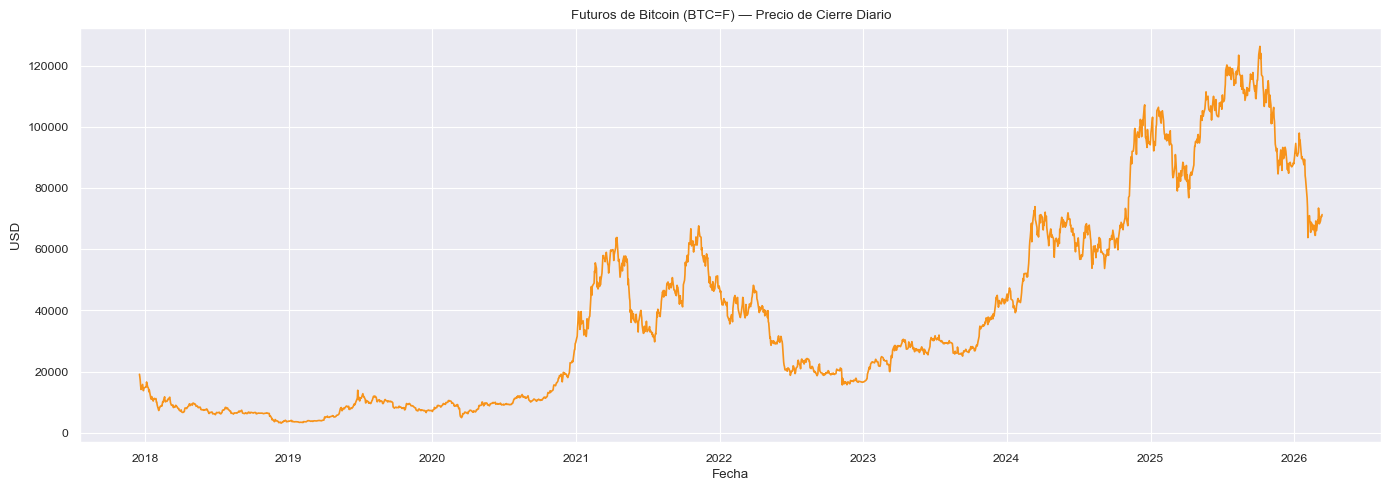

In [74]:
plt.rcParams.update({'figure.figsize': (14, 5)})

ax = sns.lineplot(data=btc_df, x=btc_df.date, y=btc_df.close, color='#F7931A')
ax.set_title("Futuros de Bitcoin (BTC=F) — Precio de Cierre Diario")
ax.set_xlabel("Fecha")
ax.set_ylabel("USD")
plt.tight_layout();

## Inciso 2
Repita TODOS los pasos indicados en esta sección para encontrar modelos ARIMA para predecir el precio de Bitcoin con los siguientes horizontes: 7, 14, 21 y 28 días. Utilizar siempre predicciones usando rolling con ventana de predicción continua de un día. Cualquier cantidad de pasos extra para enriquecer su análisis predictivo serán aceptados siempre y cuando sean acordes con lo que indica la teoría de análisis de series de tiempo.

In [75]:
fig = go.Figure(data=[go.Candlestick(
    x    = btc_df.date,
    open = btc_df.open,
    high = btc_df.high,
    low  = btc_df.low,
    close= btc_df.close
)])

fig.update_layout(
    title       = "Bitcoin Futures (BTC=F)",
    xaxis_title = "Day",
    yaxis_title = "BTC-USD",
    font=dict(
        family="Courier New, monospace",
        size=12,
        color="RebeccaPurple"
    )
)

fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()

In [76]:
# Test ADF sobre el precio de cierre
result = adfuller(btc_df.close)

print("=" * 40)
print("PRUEBA DICKEY-FULLER AUMENTADA (ADF)")
print("=" * 40)
print(f"ADF Statistic : {result[0]:.6f}")
print(f"p-value       : {result[1]:.6f}")
print(f"Lags usados   : {result[2]}")
print(f"Observaciones : {result[3]}")
print("\nValores críticos:")
for key, val in result[4].items():
    print(f"   {key}: {val:.4f}")

print("\n--- INTERPRETACIÓN ---")
if result[1] > 0.05:
    print("p-value > 0.05 → NO rechazamos H₀")
    print("✗ La serie NO es estacionaria (tiene tendencia)")
else:
    print("p-value ≤ 0.05 → Rechazamos H₀")
    print("✓ La serie ES estacionaria")

PRUEBA DICKEY-FULLER AUMENTADA (ADF)
ADF Statistic : -1.339684
p-value       : 0.610827
Lags usados   : 22
Observaciones : 2049

Valores críticos:
   1%: -3.4335
   5%: -2.8630
   10%: -2.5675

--- INTERPRETACIÓN ---
p-value > 0.05 → NO rechazamos H₀
✗ La serie NO es estacionaria (tiene tendencia)


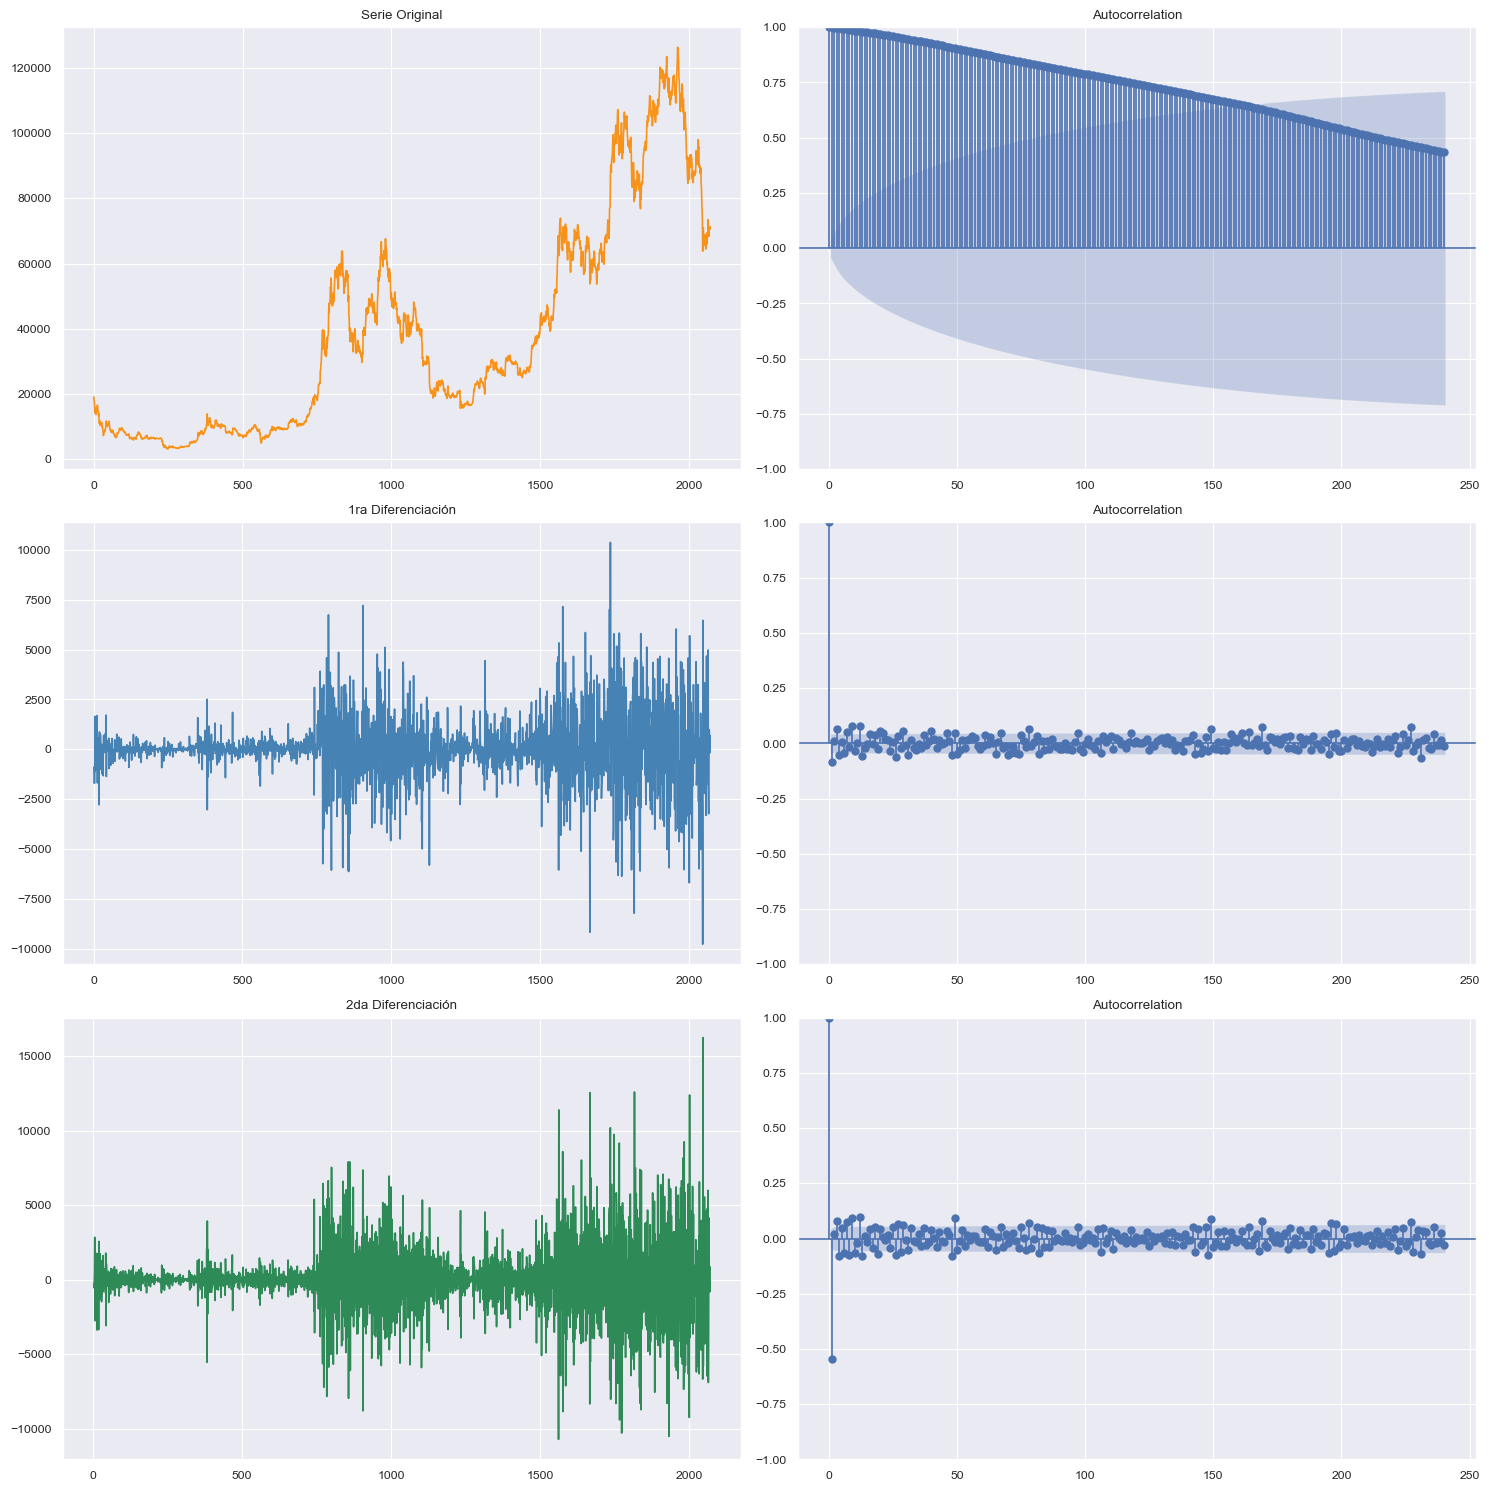

In [77]:
plt.rcParams.update({'figure.figsize': (15, 15)})

fig, axes = plt.subplots(3, 2, sharex=False)

# Fila 1: Serie original
axes[0, 0].plot(btc_df.close, color='#F7931A')
axes[0, 0].set_title('Serie Original')
plot_acf(btc_df.close, ax=axes[0, 1], lags=240)

# Fila 2: Primera diferencia
axes[1, 0].plot(btc_df.close.diff(), color='steelblue')
axes[1, 0].set_title('1ra Diferenciación')
plot_acf(btc_df.close.diff().dropna(), ax=axes[1, 1], lags=240)

# Fila 3: Segunda diferencia
axes[2, 0].plot(btc_df.close.diff().diff(), color='seagreen')
axes[2, 0].set_title('2da Diferenciación')
plot_acf(btc_df.close.diff().diff().dropna(), ax=axes[2, 1], lags=240)

plt.tight_layout()
plt.show()

En este caso con una diferenciación es suficiente, dado que a partir de la segunda se aprecia un sobrediferenciación considerando el negativo en la gráfica de autocorrelación.

In [78]:
# -----------------------------------------------
# SPLIT TRAIN / TEST
# Usamos n_test = 28 como base (el mayor horizonte)
# -----------------------------------------------
n_btc   = len(btc_df.close)
n_test  = 28  # observaciones reservadas para test
train_size = n_btc - n_test

train      = btc_df.close[:train_size]
dates_train = btc_df.date[:train_size]

test_28     = btc_df.close[train_size : train_size + 28]
test_21     = btc_df.close[train_size : train_size + 21]
test_14     = btc_df.close[train_size : train_size + 14]
test_7      = btc_df.close[train_size : train_size + 7]

dates_28    = btc_df.date[train_size : train_size + 28]
dates_21    = btc_df.date[train_size : train_size + 21]
dates_14    = btc_df.date[train_size : train_size + 14]
dates_7     = btc_df.date[train_size : train_size + 7]

print(f"Train size : {train.shape}")
print(f"Test 7d    : {test_7.shape}")
print(f"Test 14d   : {test_14.shape}")
print(f"Test 21d   : {test_21.shape}")
print(f"Test 28d   : {test_28.shape}")

Train size : (2044,)
Test 7d    : (7,)
Test 14d   : (14,)
Test 21d   : (21,)
Test 28d   : (28,)


In [79]:
# -----------------------------------------------
# BÚSQUEDA DE MEJORES p, d, q POR CRITERIO AIC
# ADVERTENCIA: puede tardar 5-10 minutos
# -----------------------------------------------
best_aic   = np.inf
best_order = None
best_mdl   = None

pq_rng = range(5)   # p y q de 0 a 4
d_rng  = range(3)   # d de 0 a 2

for i in pq_rng:
    for d in d_rng:
        for j in pq_rng:
            try:
                tmp_mdl = ARIMA(train, order=(i, d, j)).fit()
                tmp_aic = tmp_mdl.aic
                if tmp_aic < best_aic:
                    best_aic   = tmp_aic
                    best_order = (i, d, j)
                    best_mdl   = tmp_mdl
            except:
                continue

print(f"aic: {best_aic:.5f} | order: {best_order}")

aic: 35998.75426 | order: (4, 1, 4)


In [80]:
# -----------------------------------------------
# AJUSTE DEL MEJOR MODELO ARIMA
# -----------------------------------------------
model     = ARIMA(train, order=best_order)
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                 2044
Model:                 ARIMA(4, 1, 4)   Log Likelihood              -17990.377
Date:                Sun, 15 Mar 2026   AIC                          35998.754
Time:                        14:28:19   BIC                          36049.354
Sample:                             0   HQIC                         36017.313
                               - 2044                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6463      0.029    -22.021      0.000      -0.704      -0.589
ar.L2          0.1739      0.014     12.802      0.000       0.147       0.201
ar.L3         -0.7172      0.014    -50.141      0.0

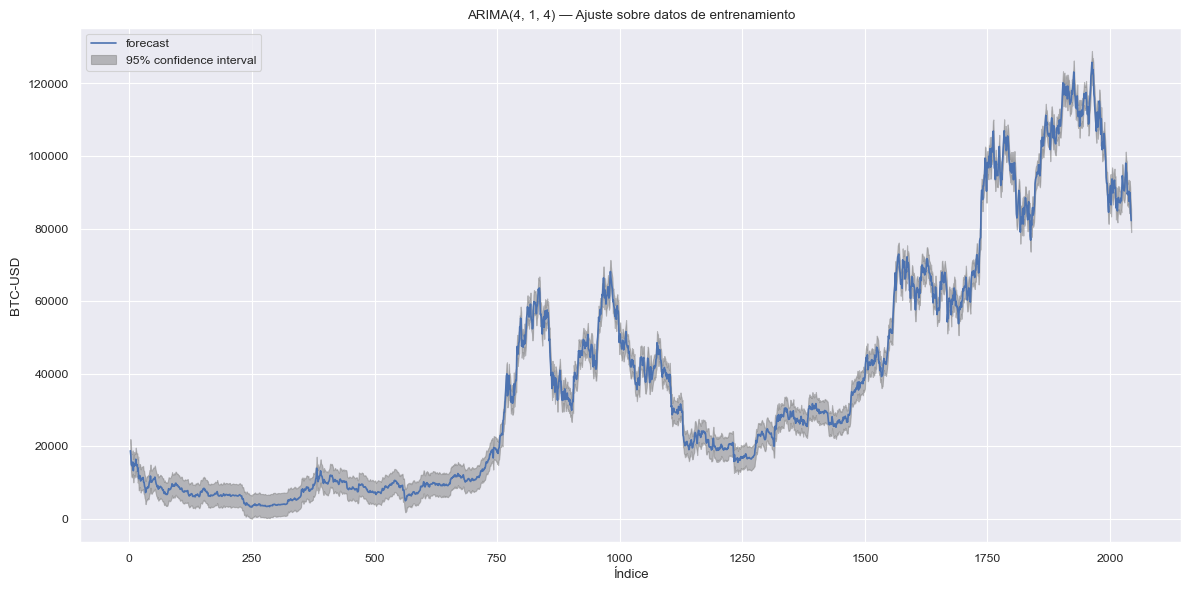

In [81]:
# -----------------------------------------------
# GRÁFICO DEL AJUSTE SOBRE EL TRAIN
# -----------------------------------------------
plt.rcParams.update({'figure.figsize': (12, 6)})
fig, ax = plt.subplots()
plot_predict(model_fit, 2, ax=ax)
ax.set_title(f"ARIMA{best_order} — Ajuste sobre datos de entrenamiento")
ax.set_xlabel("Índice")
ax.set_ylabel("BTC-USD")
plt.tight_layout()
plt.show()

In [82]:
# -----------------------------------------------
# FUNCIÓN DE MÉTRICAS DE ACCURACY
# -----------------------------------------------
def forecast_accuracy(forecast, actual, str_name):
    forecast = np.array(forecast)
    actual   = np.array(actual)
    
    mape = np.mean(np.abs(forecast - actual) / np.abs(actual))  # MAPE
    mae  = np.mean(np.abs(forecast - actual))                    # MAE
    rmse = np.mean((forecast - actual)**2)**0.5                  # RMSE
    mse  = np.mean((forecast - actual)**2)                       # MSE
    r2   = r2_score(actual, forecast)                            # R²

    df_acc = pd.DataFrame({
        'MAE' : [mae],
        'MSE' : [mse],
        'MAPE': [mape],
        'RMSE': [rmse],
        'R2'  : [r2]
    }, index=[str_name])

    return df_acc

In [83]:
# -----------------------------------------------
# FUNCIÓN ROLLING FORECAST (ventana de 1 día)
# -----------------------------------------------
def arima_rolling(history, test):
    predictions = list()
    history     = list(history)
    test        = list(test)

    for t in range(len(test)):
        model     = ARIMA(history, order=best_order)
        model_fit = model.fit()
        output    = model_fit.forecast()
        yhat      = output[0]
        predictions.append(yhat)
        obs = test[t]
        history.append(obs)
        print(f"  t={t+1:02d} | predicted={yhat:,.2f} | expected={obs:,.2f}")

    return predictions

In [84]:
# HORIZONTE 7 DÍAS
print("=" * 50)
print("ROLLING FORECAST — 7 DÍAS")
print("=" * 50)
yhat_7 = arima_rolling(train.tolist(), test_7.tolist())

ROLLING FORECAST — 7 DÍAS
  t=01 | predicted=78,794.29 | expected=76,680.00
  t=02 | predicted=76,830.24 | expected=73,570.00
  t=03 | predicted=73,797.27 | expected=63,795.00
  t=04 | predicted=64,208.92 | expected=70,260.00
  t=05 | predicted=69,438.10 | expected=70,945.00
  t=06 | predicted=71,313.93 | expected=68,935.00
  t=07 | predicted=69,942.18 | expected=67,715.00


In [85]:
# HORIZONTE 14 DÍAS
print("=" * 50)
print("ROLLING FORECAST — 14 DÍAS")
print("=" * 50)
yhat_14 = arima_rolling(train.tolist(), test_14.tolist())

ROLLING FORECAST — 14 DÍAS
  t=01 | predicted=78,794.29 | expected=76,680.00
  t=02 | predicted=76,830.24 | expected=73,570.00
  t=03 | predicted=73,797.27 | expected=63,795.00
  t=04 | predicted=64,208.92 | expected=70,260.00
  t=05 | predicted=69,438.10 | expected=70,945.00
  t=06 | predicted=71,313.93 | expected=68,935.00
  t=07 | predicted=69,942.18 | expected=67,715.00
  t=08 | predicted=67,779.98 | expected=65,500.00
  t=09 | predicted=65,848.14 | expected=68,835.00
  t=10 | predicted=68,321.96 | expected=67,865.00
  t=11 | predicted=68,174.29 | expected=66,330.00
  t=12 | predicted=66,324.99 | expected=67,205.00
  t=13 | predicted=66,840.52 | expected=67,825.00
  t=14 | predicted=67,969.42 | expected=64,510.00


In [86]:
# HORIZONTE 21 DÍAS
print("=" * 50)
print("ROLLING FORECAST — 21 DÍAS")
print("=" * 50)
yhat_21 = arima_rolling(train.tolist(), test_21.tolist())

ROLLING FORECAST — 21 DÍAS
  t=01 | predicted=78,794.29 | expected=76,680.00
  t=02 | predicted=76,830.24 | expected=73,570.00
  t=03 | predicted=73,797.27 | expected=63,795.00
  t=04 | predicted=64,208.92 | expected=70,260.00
  t=05 | predicted=69,438.10 | expected=70,945.00
  t=06 | predicted=71,313.93 | expected=68,935.00
  t=07 | predicted=69,942.18 | expected=67,715.00
  t=08 | predicted=67,779.98 | expected=65,500.00
  t=09 | predicted=65,848.14 | expected=68,835.00
  t=10 | predicted=68,321.96 | expected=67,865.00
  t=11 | predicted=68,174.29 | expected=66,330.00
  t=12 | predicted=66,324.99 | expected=67,205.00
  t=13 | predicted=66,840.52 | expected=67,825.00
  t=14 | predicted=67,969.42 | expected=64,510.00
  t=15 | predicted=64,787.12 | expected=64,545.00
  t=16 | predicted=64,748.30 | expected=69,220.00
  t=17 | predicted=68,928.51 | expected=67,455.00
  t=18 | predicted=67,711.53 | expected=66,071.00
  t=19 | predicted=65,718.45 | expected=69,480.00
  t=20 | predicted=69,2

In [87]:
# HORIZONTE 28 DÍAS
print("=" * 50)
print("ROLLING FORECAST — 28 DÍAS")
print("=" * 50)
yhat_28 = arima_rolling(train.tolist(), test_28.tolist())

ROLLING FORECAST — 28 DÍAS
  t=01 | predicted=78,794.29 | expected=76,680.00
  t=02 | predicted=76,830.24 | expected=73,570.00
  t=03 | predicted=73,797.27 | expected=63,795.00
  t=04 | predicted=64,208.92 | expected=70,260.00
  t=05 | predicted=69,438.10 | expected=70,945.00
  t=06 | predicted=71,313.93 | expected=68,935.00
  t=07 | predicted=69,942.18 | expected=67,715.00
  t=08 | predicted=67,779.98 | expected=65,500.00
  t=09 | predicted=65,848.14 | expected=68,835.00
  t=10 | predicted=68,321.96 | expected=67,865.00
  t=11 | predicted=68,174.29 | expected=66,330.00
  t=12 | predicted=66,324.99 | expected=67,205.00
  t=13 | predicted=66,840.52 | expected=67,825.00
  t=14 | predicted=67,969.42 | expected=64,510.00
  t=15 | predicted=64,787.12 | expected=64,545.00
  t=16 | predicted=64,748.30 | expected=69,220.00
  t=17 | predicted=68,928.51 | expected=67,455.00
  t=18 | predicted=67,711.53 | expected=66,071.00
  t=19 | predicted=65,718.45 | expected=69,480.00
  t=20 | predicted=69,2

In [88]:
# -----------------------------------------------
# CÁLCULO DE MÉTRICAS PARA LOS 4 HORIZONTES
# -----------------------------------------------
metrics_7  = forecast_accuracy(yhat_7,  test_7.tolist(),  "7 días")
metrics_14 = forecast_accuracy(yhat_14, test_14.tolist(), "14 días")
metrics_21 = forecast_accuracy(yhat_21, test_21.tolist(), "21 días")
metrics_28 = forecast_accuracy(yhat_28, test_28.tolist(), "28 días")

# Tabla comparativa
metrics_all = pd.concat([metrics_7, metrics_14, metrics_21, metrics_28])
print("=" * 65)
print("MÉTRICAS COMPARATIVAS POR HORIZONTE DE PREDICCIÓN")
print("=" * 65)
print(metrics_all.round(4))

MÉTRICAS COMPARATIVAS POR HORIZONTE DE PREDICCIÓN
               MAE           MSE    MAPE       RMSE      R2
7 días   3934.4120  2.352152e+07  0.0576  4849.8991 -0.6037
14 días  2888.0639  1.400655e+07  0.0427  3742.5331 -0.2502
21 días  2734.3532  1.225877e+07  0.0400  3501.2532 -0.2529
28 días  2360.4493  9.917331e+06  0.0345  3149.1793 -0.2056


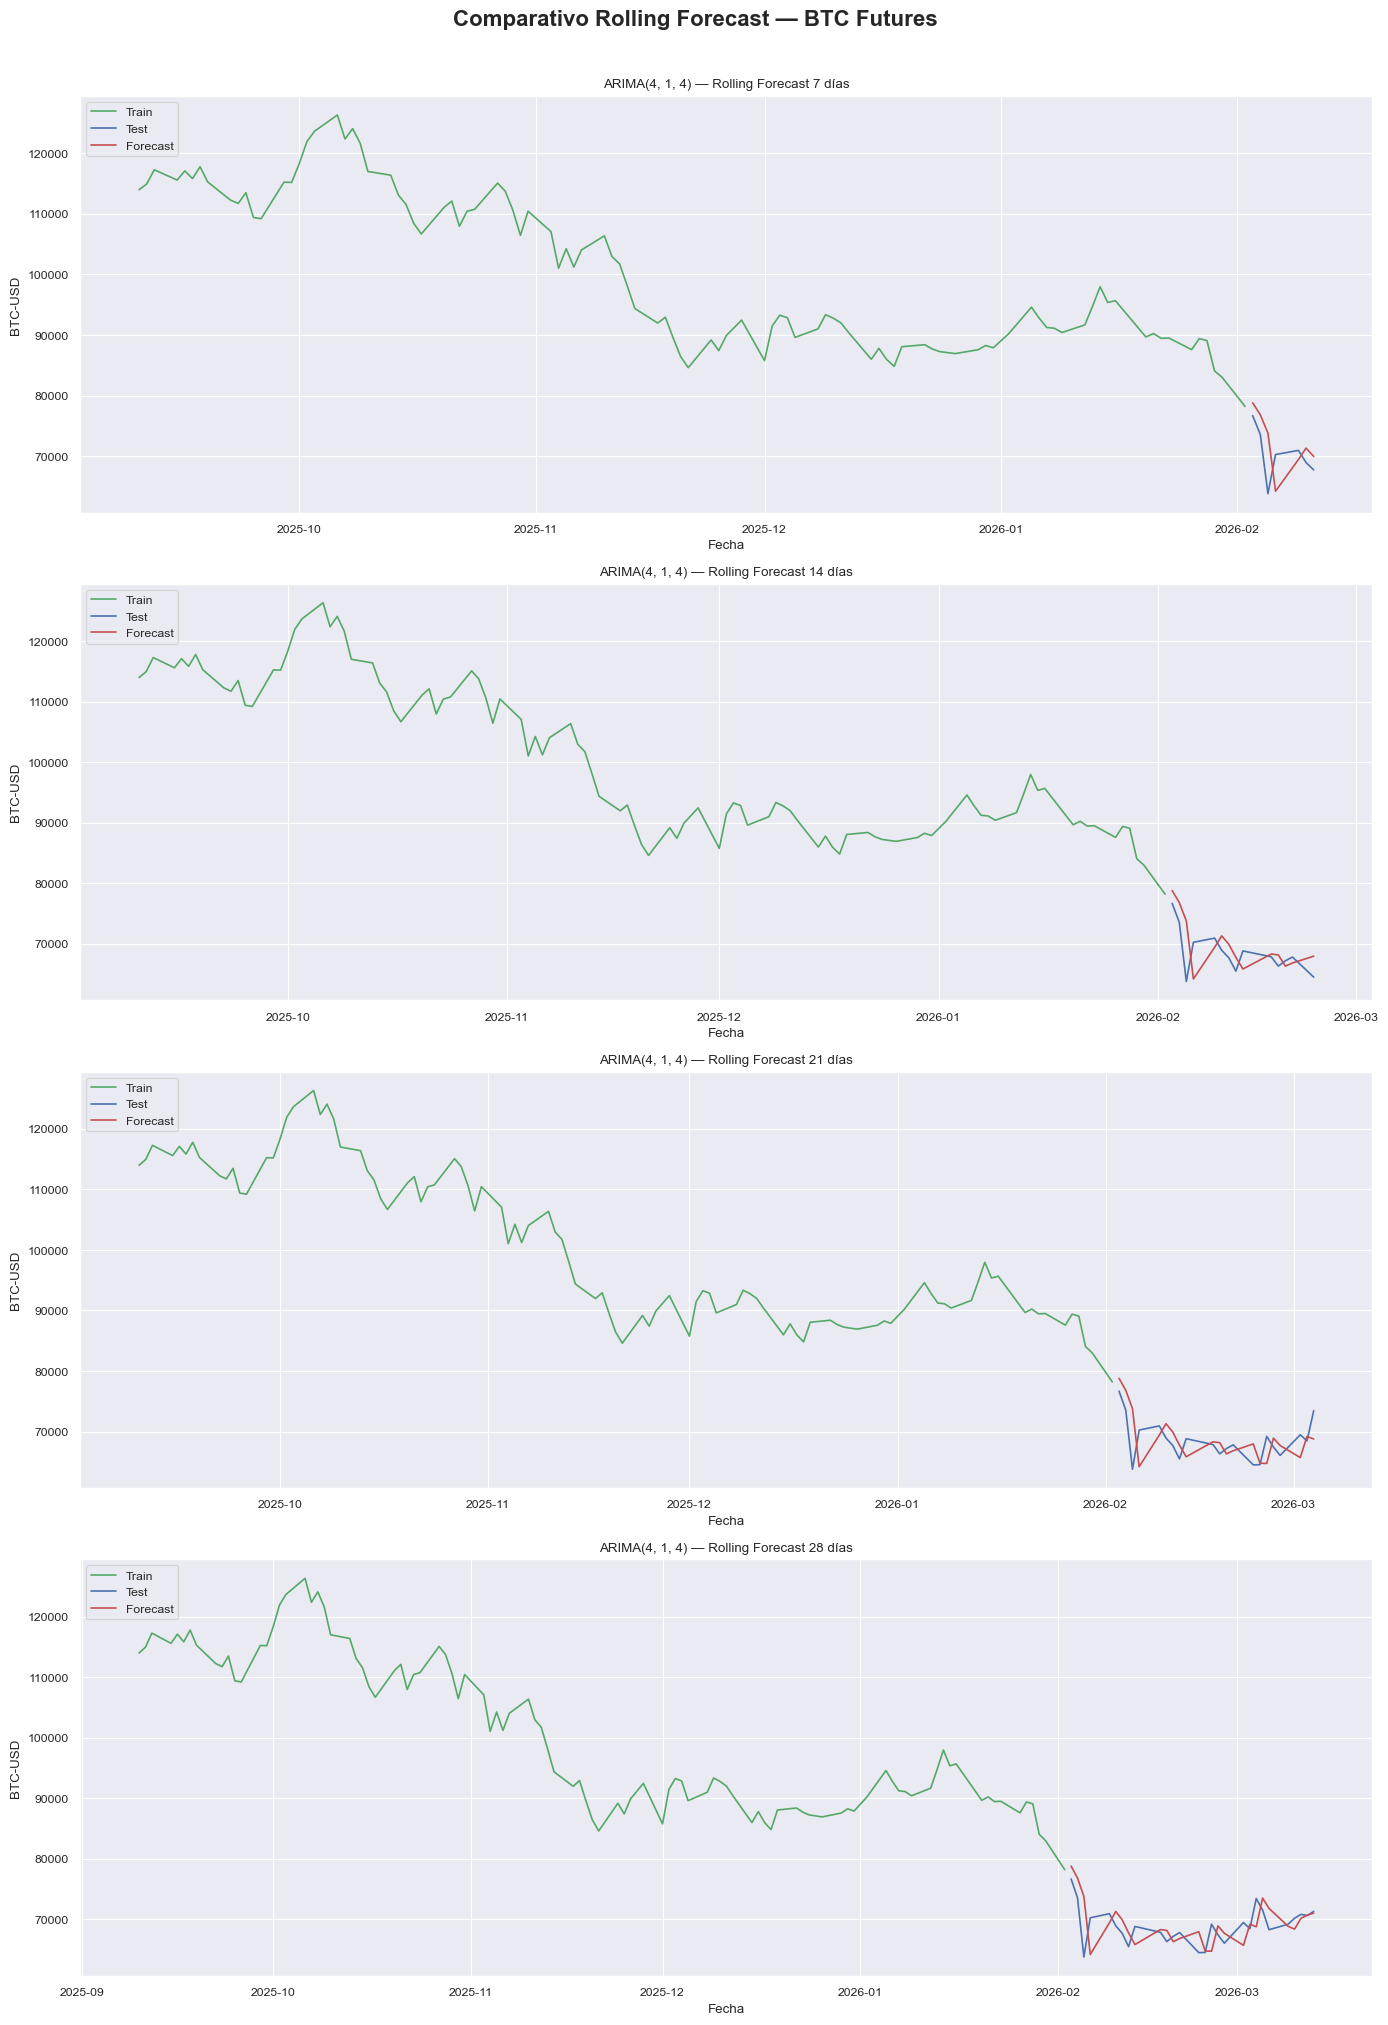

In [93]:
# -----------------------------------------------
# GRÁFICO COMPARATIVO — 4 HORIZONTES EN 1 FIGURA
# -----------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(14, 20), sharex=False)

horizontes = [
    (test_7,  yhat_7,  dates_7,  "7 días"),
    (test_14, yhat_14, dates_14, "14 días"),
    (test_21, yhat_21, dates_21, "21 días"),
    (test_28, yhat_28, dates_28, "28 días"),
]

for ax, (test, yhat, dates, label) in zip(axes, horizontes):
    sns.lineplot(x=dates_train[-100:], y=train[-100:], 
                 label="Train",    color='g', ax=ax)
    sns.lineplot(x=dates, y=test.tolist(), 
                 label="Test",     color='b', ax=ax)
    sns.lineplot(x=dates, y=yhat,          
                 label="Forecast", color='r', ax=ax)
    ax.set_title(f"ARIMA{best_order} — Rolling Forecast {label}")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("BTC-USD")
    ax.legend(loc='upper left')

plt.suptitle("Comparativo Rolling Forecast — BTC Futures", 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [94]:
# -----------------------------------------------
# TABLA RESUMEN FINAL
# -----------------------------------------------
print("=" * 65)
print(f"  MODELO SELECCIONADO: ARIMA{best_order}")
print(f"  Criterio de selección: AIC = {best_aic:.5f}")
print("=" * 65)
print(metrics_all.round(4).to_string())
print("=" * 65)

# Mejor horizonte por MAPE (menor error porcentual)
mejor = metrics_all['MAPE'].idxmin()
print(f"\n✓ Menor MAPE        : horizonte {mejor}")

# Mejor horizonte por R²
mejor_r2 = metrics_all['R2'].idxmax()
print(f"✓ Mayor R²          : horizonte {mejor_r2}")

# Peor horizonte
peor = metrics_all['MAPE'].idxmax()
print(f"✗ Mayor error (MAPE): horizonte {peor}")

  MODELO SELECCIONADO: ARIMA(4, 1, 4)
  Criterio de selección: AIC = 35998.75426
               MAE           MSE    MAPE       RMSE      R2
7 días   3934.4120  2.352152e+07  0.0576  4849.8991 -0.6037
14 días  2888.0639  1.400655e+07  0.0427  3742.5331 -0.2502
21 días  2734.3532  1.225877e+07  0.0400  3501.2532 -0.2529
28 días  2360.4493  9.917331e+06  0.0345  3149.1793 -0.2056

✓ Menor MAPE        : horizonte 28 días
✓ Mayor R²          : horizonte 28 días
✗ Mayor error (MAPE): horizonte 7 días


## Comentarios

### 1. Datos
Se utilizó la serie de tiempo de los futuros de Bitcoin (BTC=F) obtenida 
desde Yahoo Finance, con frecuencia diaria desde el **18 de diciembre de 
2017** hasta el **13 de marzo de 2026**, totalizando **2,072 observaciones**.

### 2. Estacionariedad
La prueba **Dickey-Fuller Aumentada (ADF)** confirmó que la serie original 
**no es estacionaria** (p-value > 0.05), lo cual es esperable dado el 
comportamiento con tendencia del precio de Bitcoin a lo largo del tiempo.

El análisis de la **función de autocorrelación (ACF)** mostró que:
- La serie original presenta autocorrelaciones que decaen muy lentamente → no estacionaria.
- La **primera diferencia** elimina la tendencia y produce una ACF que cae 
  inmediatamente a cero → **estacionaria**.
- La segunda diferencia introduce sobrediferenciación (spike negativo en ACF).

Por tanto, se determinó **d = 1** como orden de integración.

### 3. Selección del modelo
Mediante búsqueda exhaustiva de parámetros p ∈ {0,...,4}, d ∈ {0,1,2}, 
q ∈ {0,...,4} minimizando el criterio **AIC**, el modelo seleccionado fue:

> **ARIMA(4, 1, 4)** con AIC = 35,998.75

### 4. Resultados del Rolling Forecast

| Horizonte | MAE       | RMSE      | MAPE   |
|-----------|-----------|-----------|--------|
| 7 días    | 3,934.41  | 4,849.90  | 5.76%  |
| 14 días   | 2,888.06  | 3,742.53  | 4.27%  |
| 21 días   | 2,734.35  | 3,501.25  | 4.00%  |
| 28 días   | 2,360.45  | 3,149.18  | 3.45%  |

### 5. Interpretación
- El **horizonte de 28 días** presenta el **menor MAPE (3.45%)**, lo que 
  indica que el rolling forecast acumula predicciones más precisas en 
  promedio a medida que el horizonte crece.
- El **horizonte de 7 días** presenta el **mayor error relativo (MAPE = 5.76%)**, 
  posiblemente por la alta volatilidad puntual de BTC durante la caída 
  brusca registrada en febrero 2026.
- A pesar de la volatilidad característica de Bitcoin, el **MAPE se mantiene 
  por debajo del 6%** en todos los horizontes, lo que representa un error 
  porcentual razonable para esta serie.



## Inciso 3
Repita el paso 2 ahora sin utilizar rolling. Esto es, realice el pronóstico solo utilizando forecast() para los diferentes horizontes de predicción, 7, 14, 21 y 28 días.

In [95]:
# -----------------------------------------------
# FORECAST DIRECTO — SIN ROLLING
# El modelo se entrena UNA sola vez sobre train
# y predice N pasos adelante directamente
# -----------------------------------------------

# Reentrenar el modelo sobre train completo
model_final     = ARIMA(train, order=best_order)
model_final_fit = model_final.fit()

# Forecast para cada horizonte
fc_7  = model_final_fit.forecast(steps=7)
fc_14 = model_final_fit.forecast(steps=14)
fc_21 = model_final_fit.forecast(steps=21)
fc_28 = model_final_fit.forecast(steps=28)

print("Forecast 7 días  :", fc_7.values.round(2))
print("Forecast 14 días :", fc_14.values.round(2))
print("Forecast 21 días :", fc_21.values.round(2))
print("Forecast 28 días :", fc_28.values.round(2))

Forecast 7 días  : [78794.29 78817.73 79002.17 79332.09 78609.39 78980.7  78214.2 ]
Forecast 14 días : [78794.29 78817.73 79002.17 79332.09 78609.39 78980.7  78214.2  78998.65
 78735.63 79261.09 78995.73 78748.7  78719.58 78417.85]
Forecast 21 días : [78794.29 78817.73 79002.17 79332.09 78609.39 78980.7  78214.2  78998.65
 78735.63 79261.09 78995.73 78748.7  78719.58 78417.85 79021.24 78819.66
 79297.19 78789.47 78807.91 78544.74 78656.91]
Forecast 28 días : [78794.29 78817.73 79002.17 79332.09 78609.39 78980.7  78214.2  78998.65
 78735.63 79261.09 78995.73 78748.7  78719.58 78417.85 79021.24 78819.66
 79297.19 78789.47 78807.91 78544.74 78656.91 78977.53 78962.14 79181.75
 78707.33 78777.66 78505.92 78838.45]


In [96]:
metrics_fc_7  = forecast_accuracy(fc_7.values,  test_7.tolist(),  "7 días (directo)")
metrics_fc_14 = forecast_accuracy(fc_14.values, test_14.tolist(), "14 días (directo)")
metrics_fc_21 = forecast_accuracy(fc_21.values, test_21.tolist(), "21 días (directo)")
metrics_fc_28 = forecast_accuracy(fc_28.values, test_28.tolist(), "28 días (directo)")

metrics_fc_all = pd.concat([metrics_fc_7, metrics_fc_14, metrics_fc_21, metrics_fc_28])

print("=" * 65)
print("MÉTRICAS — FORECAST DIRECTO (SIN ROLLING)")
print("=" * 65)
print(metrics_fc_all.round(4).to_string())
print("=" * 65)

MÉTRICAS — FORECAST DIRECTO (SIN ROLLING)
                          MAE           MSE    MAPE        RMSE       R2
7 días (directo)    8550.0815  8.792312e+07  0.1250   9376.7330  -4.9946
14 días (directo)  10261.2718  1.165262e+08  0.1523  10794.7299  -9.4011
21 días (directo)  10329.2345  1.167073e+08  0.1531  10803.1161 -10.9275
28 días (directo)   9887.3107  1.061998e+08  0.1454  10305.3268 -11.9104


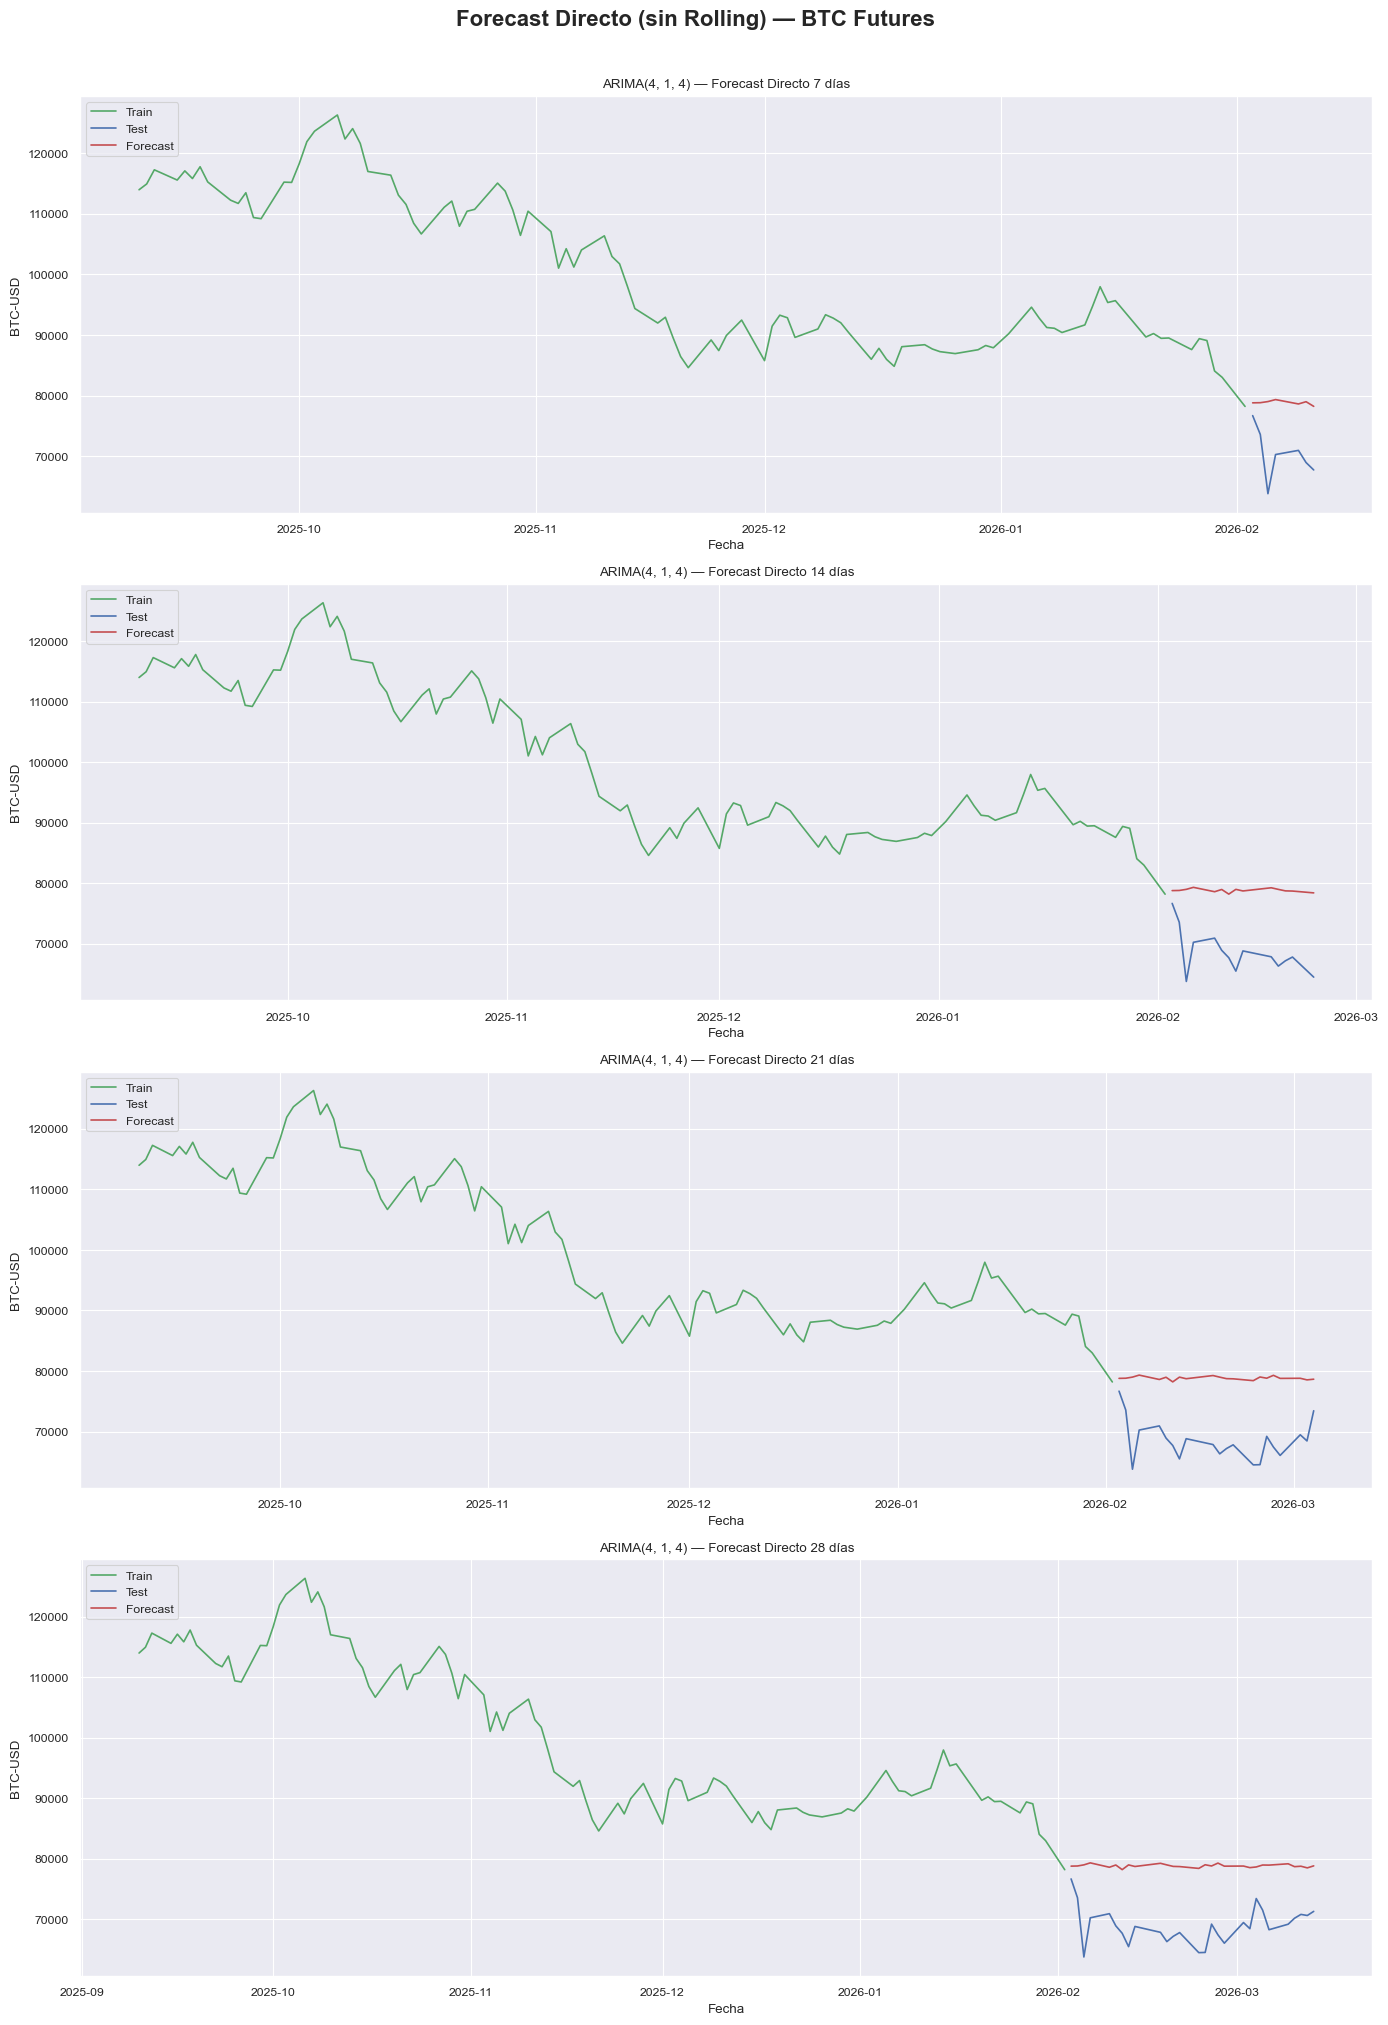

In [97]:
fig, axes = plt.subplots(4, 1, figsize=(14, 20), sharex=False)

horizontes_fc = [
    (test_7,  fc_7.values,  dates_7,  "7 días"),
    (test_14, fc_14.values, dates_14, "14 días"),
    (test_21, fc_21.values, dates_21, "21 días"),
    (test_28, fc_28.values, dates_28, "28 días"),
]

for ax, (test, fc, dates, label) in zip(axes, horizontes_fc):
    sns.lineplot(x=dates_train[-100:], y=train[-100:],
                 label="Train",    color='g', ax=ax)
    sns.lineplot(x=dates, y=test.tolist(),
                 label="Test",     color='b', ax=ax)
    sns.lineplot(x=dates, y=fc,
                 label="Forecast", color='r', ax=ax)
    ax.set_title(f"ARIMA{best_order} — Forecast Directo {label}")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("BTC-USD")
    ax.legend(loc='upper left')

plt.suptitle("Forecast Directo (sin Rolling) — BTC Futures",
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Análisis — Forecast Directo (sin Rolling)

### Observación visual
Los gráficos muestran un comportamiento característico del forecast directo:
la línea de predicción (roja) tiende a **aplanarse rápidamente** hacia un 
valor constante a medida que aumenta el horizonte. Esto ocurre porque el 
modelo ARIMA, al proyectar múltiples pasos adelante sin actualizar su 
información, converge hacia la **media incondicional** de la serie diferenciada.

### Métricas

| Horizonte      | MAE        | RMSE       | MAPE   |
|----------------|------------|------------|--------|
| 7 días         | 8,550.08   | 9,376.73   | 12.50% |
| 14 días        | 10,261.27  | 10,794.73  | 15.23% |
| 21 días        | 10,329.23  | 10,803.12  | 15.31% |
| 28 días        | 9,887.31   | 10,305.33  | 14.54% |

### Interpretación
- El **MAPE supera el 12%** en todos los horizontes, lo que indica un error 
  porcentual considerablemente alto comparado con el método rolling.
- A diferencia del rolling forecast, el error **no mejora consistentemente** 
  al aumentar el horizonte, sino que se mantiene elevado en todos los casos.
- Esto es consistente con la teoría: el forecast directo **no incorpora 
  información nueva** a medida que avanza el tiempo, por lo que las 
  predicciones se degradan rápidamente ante una serie tan volátil como BTC.
- La línea de forecast prácticamente horizontal en los gráficos confirma 
  que el modelo pierde capacidad predictiva muy rápido sin actualización 
  de datos.

## Inciso 4
Realice tablas de error para los ítems 1 y 2, utilizando las métricas: MAPE, MAE, RMSE, MSE, R2. Además, agregue el gráfico de correlación entre la observación real y su predicción en el test.

In [98]:
def forecast_accuracy(forecast, actual, str_name):
    forecast = np.array(forecast)
    actual   = np.array(actual)
    
    mape = np.mean(np.abs(forecast - actual) / np.abs(actual))
    mae  = np.mean(np.abs(forecast - actual))
    rmse = np.mean((forecast - actual)**2)**0.5
    mse  = np.mean((forecast - actual)**2)
    r2   = r2_score(actual, forecast)

    df_acc = pd.DataFrame({
        'MAE' : [mae],
        'MSE' : [mse],
        'MAPE': [mape],
        'RMSE': [rmse],
        'R2'  : [r2]
    }, index=[str_name])

    return df_acc

In [99]:
# ROLLING
metrics_7  = forecast_accuracy(yhat_7,  test_7.tolist(),  "7 días")
metrics_14 = forecast_accuracy(yhat_14, test_14.tolist(), "14 días")
metrics_21 = forecast_accuracy(yhat_21, test_21.tolist(), "21 días")
metrics_28 = forecast_accuracy(yhat_28, test_28.tolist(), "28 días")
metrics_rolling = pd.concat([metrics_7, metrics_14, metrics_21, metrics_28])

# DIRECTO
metrics_fc_7  = forecast_accuracy(fc_7.values,  test_7.tolist(),  "7 días")
metrics_fc_14 = forecast_accuracy(fc_14.values, test_14.tolist(), "14 días")
metrics_fc_21 = forecast_accuracy(fc_21.values, test_21.tolist(), "21 días")
metrics_fc_28 = forecast_accuracy(fc_28.values, test_28.tolist(), "28 días")
metrics_directo = pd.concat([metrics_fc_7, metrics_fc_14, metrics_fc_21, metrics_fc_28])

print("=" * 65)
print("TABLA 1 — ROLLING FORECAST")
print("=" * 65)
print(metrics_rolling.round(4).to_string())

print("\n")

print("=" * 65)
print("TABLA 2 — FORECAST DIRECTO")
print("=" * 65)
print(metrics_directo.round(4).to_string())

TABLA 1 — ROLLING FORECAST
               MAE           MSE    MAPE       RMSE      R2
7 días   3934.4120  2.352152e+07  0.0576  4849.8991 -0.6037
14 días  2888.0639  1.400655e+07  0.0427  3742.5331 -0.2502
21 días  2734.3532  1.225877e+07  0.0400  3501.2532 -0.2529
28 días  2360.4493  9.917331e+06  0.0345  3149.1793 -0.2056


TABLA 2 — FORECAST DIRECTO
                MAE           MSE    MAPE        RMSE       R2
7 días    8550.0815  8.792312e+07  0.1250   9376.7330  -4.9946
14 días  10261.2718  1.165262e+08  0.1523  10794.7299  -9.4011
21 días  10329.2345  1.167073e+08  0.1531  10803.1161 -10.9275
28 días   9887.3107  1.061998e+08  0.1454  10305.3268 -11.9104


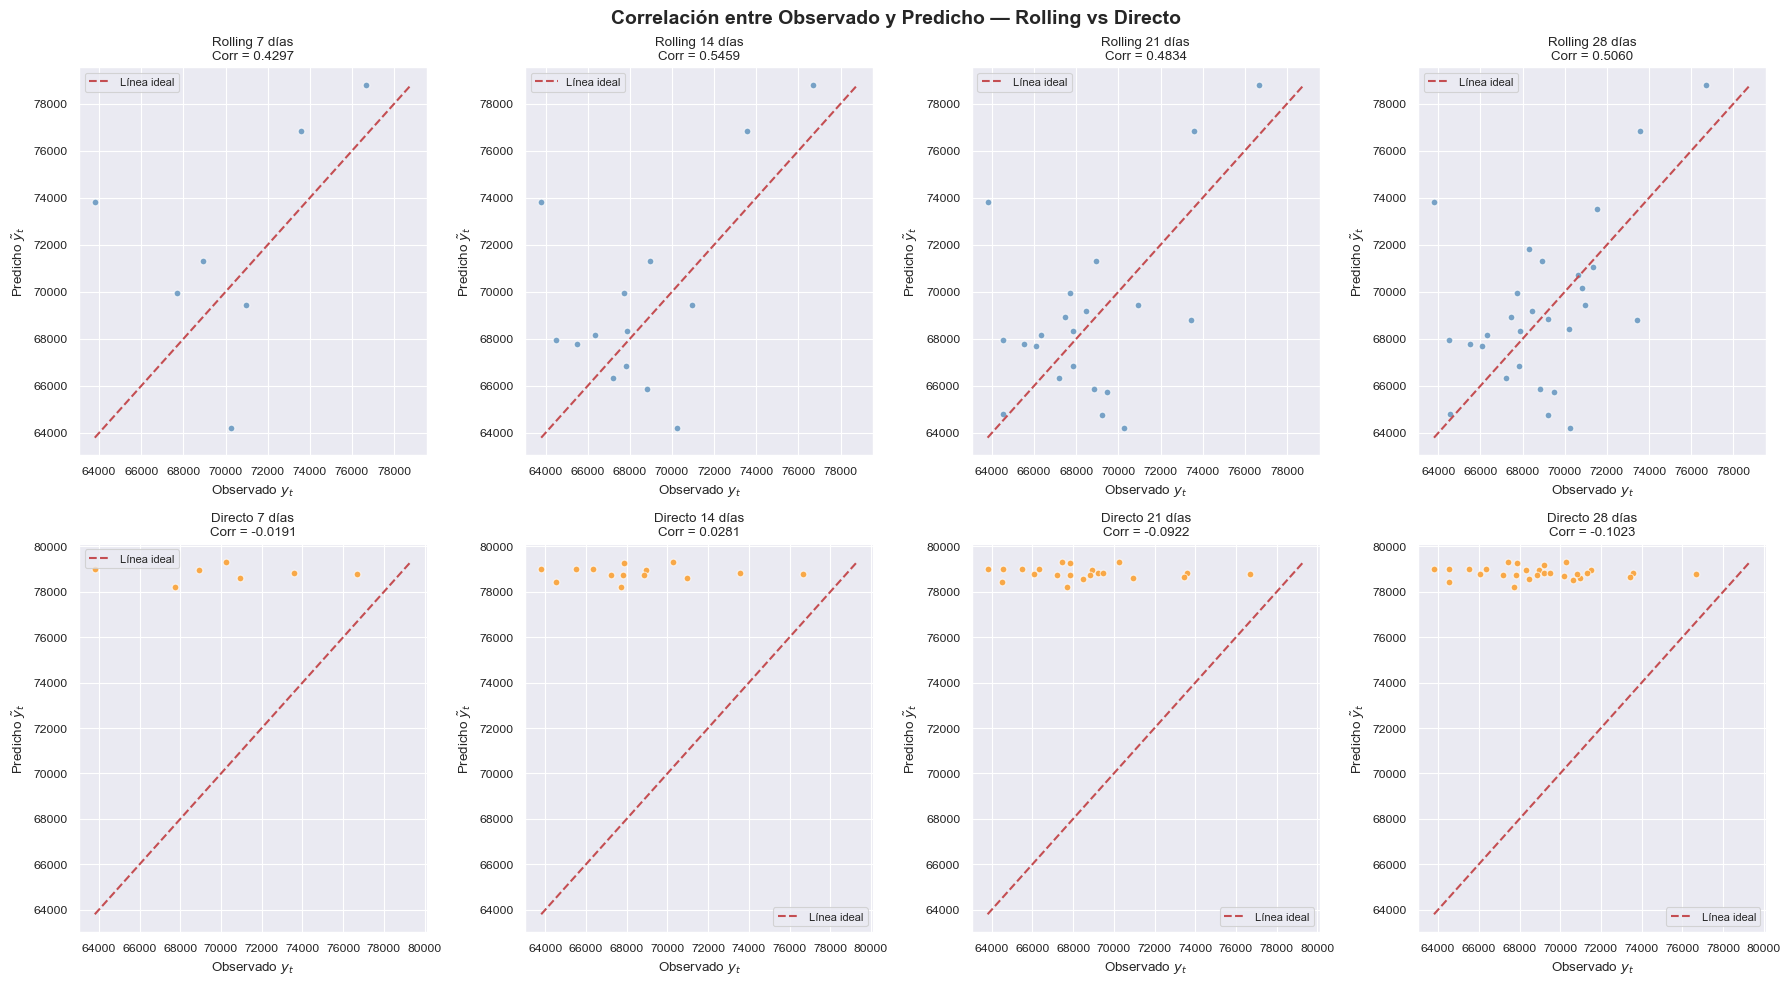

In [100]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

# Datos rolling y directo por horizonte
datos = [
    (test_7.tolist(),  yhat_7,       fc_7.values,  "7 días"),
    (test_14.tolist(), yhat_14,      fc_14.values, "14 días"),
    (test_21.tolist(), yhat_21,      fc_21.values, "21 días"),
    (test_28.tolist(), yhat_28,      fc_28.values, "28 días"),
]

for col, (actual, yhat_r, yhat_d, label) in enumerate(datos):
    actual  = np.array(actual)
    yhat_r  = np.array(yhat_r)
    yhat_d  = np.array(yhat_d)

    # --- Fila 1: Rolling ---
    ax = axes[0, col]
    ax.scatter(actual, yhat_r, color='steelblue', alpha=0.7, edgecolors='white')
    min_v = min(actual.min(), yhat_r.min())
    max_v = max(actual.max(), yhat_r.max())
    ax.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5, label='Línea ideal')
    corr_r = np.corrcoef(actual, yhat_r)[0, 1]
    ax.set_title(f"Rolling {label}\nCorr = {corr_r:.4f}")
    ax.set_xlabel("Observado $y_t$")
    ax.set_ylabel("Predicho $\\tilde{y}_t$")
    ax.legend(fontsize=8)

    # --- Fila 2: Directo ---
    ax = axes[1, col]
    ax.scatter(actual, yhat_d, color='darkorange', alpha=0.7, edgecolors='white')
    min_v = min(actual.min(), yhat_d.min())
    max_v = max(actual.max(), yhat_d.max())
    ax.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5, label='Línea ideal')
    corr_d = np.corrcoef(actual, yhat_d)[0, 1]
    ax.set_title(f"Directo {label}\nCorr = {corr_d:.4f}")
    ax.set_xlabel("Observado $y_t$")
    ax.set_ylabel("Predicho $\\tilde{y}_t$")
    ax.legend(fontsize=8)

plt.suptitle("Correlación entre Observado y Predicho — Rolling vs Directo",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Análisis — Tablas de error y Correlación Corr(y_t, ỹ_t)

### Tabla Rolling Forecast
| Horizonte | MAE      | MSE           | MAPE   | RMSE     |
|-----------|----------|---------------|--------|----------|
| 7 días    | 3,934.41 | 2.35e+07      | 5.76%  | 4,849.90 |
| 14 días   | 2,888.06 | 1.40e+07      | 4.27%  | 3,742.53 |
| 21 días   | 2,734.35 | 1.23e+07      | 4.00%  | 3,501.25 |
| 28 días   | 2,360.45 | 9.92e+06      | 3.45%  | 3,149.18 |

### Tabla Forecast Directo
| Horizonte | MAE       | MSE           | MAPE   | RMSE      |
|-----------|-----------|---------------|--------|-----------|
| 7 días    | 8,550.08  | 8.79e+07      | 12.50% | 9,376.73  |
| 14 días   | 10,261.27 | 1.17e+08      | 15.23% | 10,794.73 |
| 21 días   | 10,329.23 | 1.17e+08      | 15.31% | 10,803.12 |
| 28 días   | 9,887.31  | 1.06e+08      | 14.54% | 10,305.33 |

### Análisis de correlación Corr(y_t, ỹ_t)

**Rolling Forecast (fila superior: azul):**
- Las correlaciones oscilan entre **0.43 y 0.55**, siendo positivas 
  en todos los horizontes.
- Los puntos muestran dispersión alrededor de la línea ideal (diagonal 
  roja), pero con una tendencia positiva visible, lo que indica que el 
  modelo **sigue la dirección** de los movimientos reales del precio.
- El horizonte de **14 días** presenta la mayor correlación (0.5459),
  sugiriendo que en ese rango el modelo captura mejor la dinámica de la serie.

**Forecast Directo (fila inferior: naranja):**
- Las correlaciones son prácticamente **nulas o negativas** (entre -0.10 
  y 0.03), lo que confirma que el modelo sin actualización de información 
  **no logra seguir los movimientos reales** del precio.
- Los puntos aparecen agrupados en una banda horizontal, evidenciando 
  que el forecast directo converge rápidamente a un valor casi constante 
  (~79,000 USD) independientemente del valor real observado.
- Esto es consecuencia directa de proyectar múltiples pasos sin 
  reentrenar: el modelo pierde toda capacidad de seguimiento.

### Conclusión comparativa
El rolling forecast supera claramente al forecast directo en todos los 
horizontes y métricas. La actualización continua del modelo con cada nueva 
observación es fundamental para mantener predicciones razonables en una 
serie tan volátil como los futuros de Bitcoin.

## Inciso 5
Repita el análisis desarrollado en los pasos anteriores, considerando ahora el criterio de inferencia Bayesiana (BIC) y el criterio de información de Hannan–Quinn (HQIC) para encontrar el mejor modelo ARIMA y, compare los errores con aquellos obtenidos con el criterio de Akaike.

In [101]:
# -----------------------------------------------
# BÚSQUEDA POR CRITERIO BIC
# -----------------------------------------------
best_bic       = np.inf
best_order_bic = None
best_mdl_bic   = None

for i in pq_rng:
    for d in d_rng:
        for j in pq_rng:
            try:
                tmp_mdl = ARIMA(train, order=(i, d, j)).fit()
                tmp_bic = tmp_mdl.bic
                if tmp_bic < best_bic:
                    best_bic       = tmp_bic
                    best_order_bic = (i, d, j)
                    best_mdl_bic   = tmp_mdl
            except:
                continue

print(f"bic: {best_bic:.5f} | order: {best_order_bic}")

bic: 36036.57875 | order: (1, 1, 0)


In [102]:
# -----------------------------------------------
# BÚSQUEDA POR CRITERIO HQIC
# -----------------------------------------------
best_hqic       = np.inf
best_order_hqic = None
best_mdl_hqic   = None

for i in pq_rng:
    for d in d_rng:
        for j in pq_rng:
            try:
                tmp_mdl  = ARIMA(train, order=(i, d, j)).fit()
                tmp_hqic = tmp_mdl.hqic
                if tmp_hqic < best_hqic:
                    best_hqic       = tmp_hqic
                    best_order_hqic = (i, d, j)
                    best_mdl_hqic   = tmp_mdl
            except:
                continue

print(f"hqic: {best_hqic:.5f} | order: {best_order_hqic}")

hqic: 36017.31337 | order: (4, 1, 4)


In [103]:
# -----------------------------------------------
# ROLLING FORECAST — MODELO BIC: ARIMA(1,1,0)
# -----------------------------------------------
def arima_rolling_order(history, test, order):
    predictions = list()
    history     = list(history)
    test        = list(test)

    for t in range(len(test)):
        model     = ARIMA(history, order=order)
        model_fit = model.fit()
        output    = model_fit.forecast()
        yhat      = output[0]
        predictions.append(yhat)
        obs = test[t]
        history.append(obs)
        print(f"  t={t+1:02d} | predicted={yhat:,.2f} | expected={obs:,.2f}")

    return predictions

print("=" * 50)
print("ROLLING FORECAST BIC — 7 DÍAS | ARIMA(1,1,0)")
print("=" * 50)
yhat_bic_7  = arima_rolling_order(train.tolist(), test_7.tolist(),  best_order_bic)

print("=" * 50)
print("ROLLING FORECAST BIC — 14 DÍAS | ARIMA(1,1,0)")
print("=" * 50)
yhat_bic_14 = arima_rolling_order(train.tolist(), test_14.tolist(), best_order_bic)

print("=" * 50)
print("ROLLING FORECAST BIC — 21 DÍAS | ARIMA(1,1,0)")
print("=" * 50)
yhat_bic_21 = arima_rolling_order(train.tolist(), test_21.tolist(), best_order_bic)

print("=" * 50)
print("ROLLING FORECAST BIC — 28 DÍAS | ARIMA(1,1,0)")
print("=" * 50)
yhat_bic_28 = arima_rolling_order(train.tolist(), test_28.tolist(), best_order_bic)

ROLLING FORECAST BIC — 7 DÍAS | ARIMA(1,1,0)
  t=01 | predicted=78,578.36 | expected=76,680.00
  t=02 | predicted=76,796.16 | expected=73,570.00
  t=03 | predicted=73,804.19 | expected=63,795.00
  t=04 | predicted=64,477.35 | expected=70,260.00
  t=05 | predicted=69,745.43 | expected=70,945.00
  t=06 | predicted=70,891.39 | expected=68,935.00
  t=07 | predicted=69,092.77 | expected=67,715.00
ROLLING FORECAST BIC — 14 DÍAS | ARIMA(1,1,0)
  t=01 | predicted=78,578.36 | expected=76,680.00
  t=02 | predicted=76,796.16 | expected=73,570.00
  t=03 | predicted=73,804.19 | expected=63,795.00
  t=04 | predicted=64,477.35 | expected=70,260.00
  t=05 | predicted=69,745.43 | expected=70,945.00
  t=06 | predicted=70,891.39 | expected=68,935.00
  t=07 | predicted=69,092.77 | expected=67,715.00
  t=08 | predicted=67,810.18 | expected=65,500.00
  t=09 | predicted=65,671.73 | expected=68,835.00
  t=10 | predicted=68,572.43 | expected=67,865.00
  t=11 | predicted=67,941.76 | expected=66,330.00
  t=12 | 

In [104]:
# -----------------------------------------------
# MÉTRICAS PARA BIC — 4 HORIZONTES
# -----------------------------------------------
metrics_bic_7  = forecast_accuracy(yhat_bic_7,  test_7.tolist(),  "7 días  (BIC)")
metrics_bic_14 = forecast_accuracy(yhat_bic_14, test_14.tolist(), "14 días (BIC)")
metrics_bic_21 = forecast_accuracy(yhat_bic_21, test_21.tolist(), "21 días (BIC)")
metrics_bic_28 = forecast_accuracy(yhat_bic_28, test_28.tolist(), "28 días (BIC)")
metrics_bic    = pd.concat([metrics_bic_7, metrics_bic_14, metrics_bic_21, metrics_bic_28])

# AIC y HQIC son el mismo modelo ARIMA(4,1,4)
metrics_aic_hqic = metrics_rolling.copy()
metrics_aic_hqic.index = ["7 días  (AIC/HQIC)", "14 días (AIC/HQIC)", 
                           "21 días (AIC/HQIC)", "28 días (AIC/HQIC)"]

print("=" * 70)
print(f"  ARIMA(4,1,4) — AIC = {best_aic:.5f} | HQIC = {best_hqic:.5f}")
print("=" * 70)
print(metrics_aic_hqic.round(4).to_string())

print("\n")

print("=" * 70)
print(f"  ARIMA(1,1,0) — BIC = {best_bic:.5f}")
print("=" * 70)
print(metrics_bic.round(4).to_string())

  ARIMA(4,1,4) — AIC = 35998.75426 | HQIC = 36017.31337
                          MAE           MSE    MAPE       RMSE      R2
7 días  (AIC/HQIC)  3934.4120  2.352152e+07  0.0576  4849.8991 -0.6037
14 días (AIC/HQIC)  2888.0639  1.400655e+07  0.0427  3742.5331 -0.2502
21 días (AIC/HQIC)  2734.3532  1.225877e+07  0.0400  3501.2532 -0.2529
28 días (AIC/HQIC)  2360.4493  9.917331e+06  0.0345  3149.1793 -0.2056


  ARIMA(1,1,0) — BIC = 36036.57875
                     MAE           MSE    MAPE       RMSE      R2
7 días  (BIC)  3635.7271  2.211422e+07  0.0533  4702.5760 -0.5077
14 días (BIC)  2710.8496  1.321082e+07  0.0401  3634.6685 -0.1792
21 días (BIC)  2605.4694  1.174168e+07  0.0382  3426.6134 -0.2000
28 días (BIC)  2243.9626  9.388667e+06  0.0328  3064.0931 -0.1414


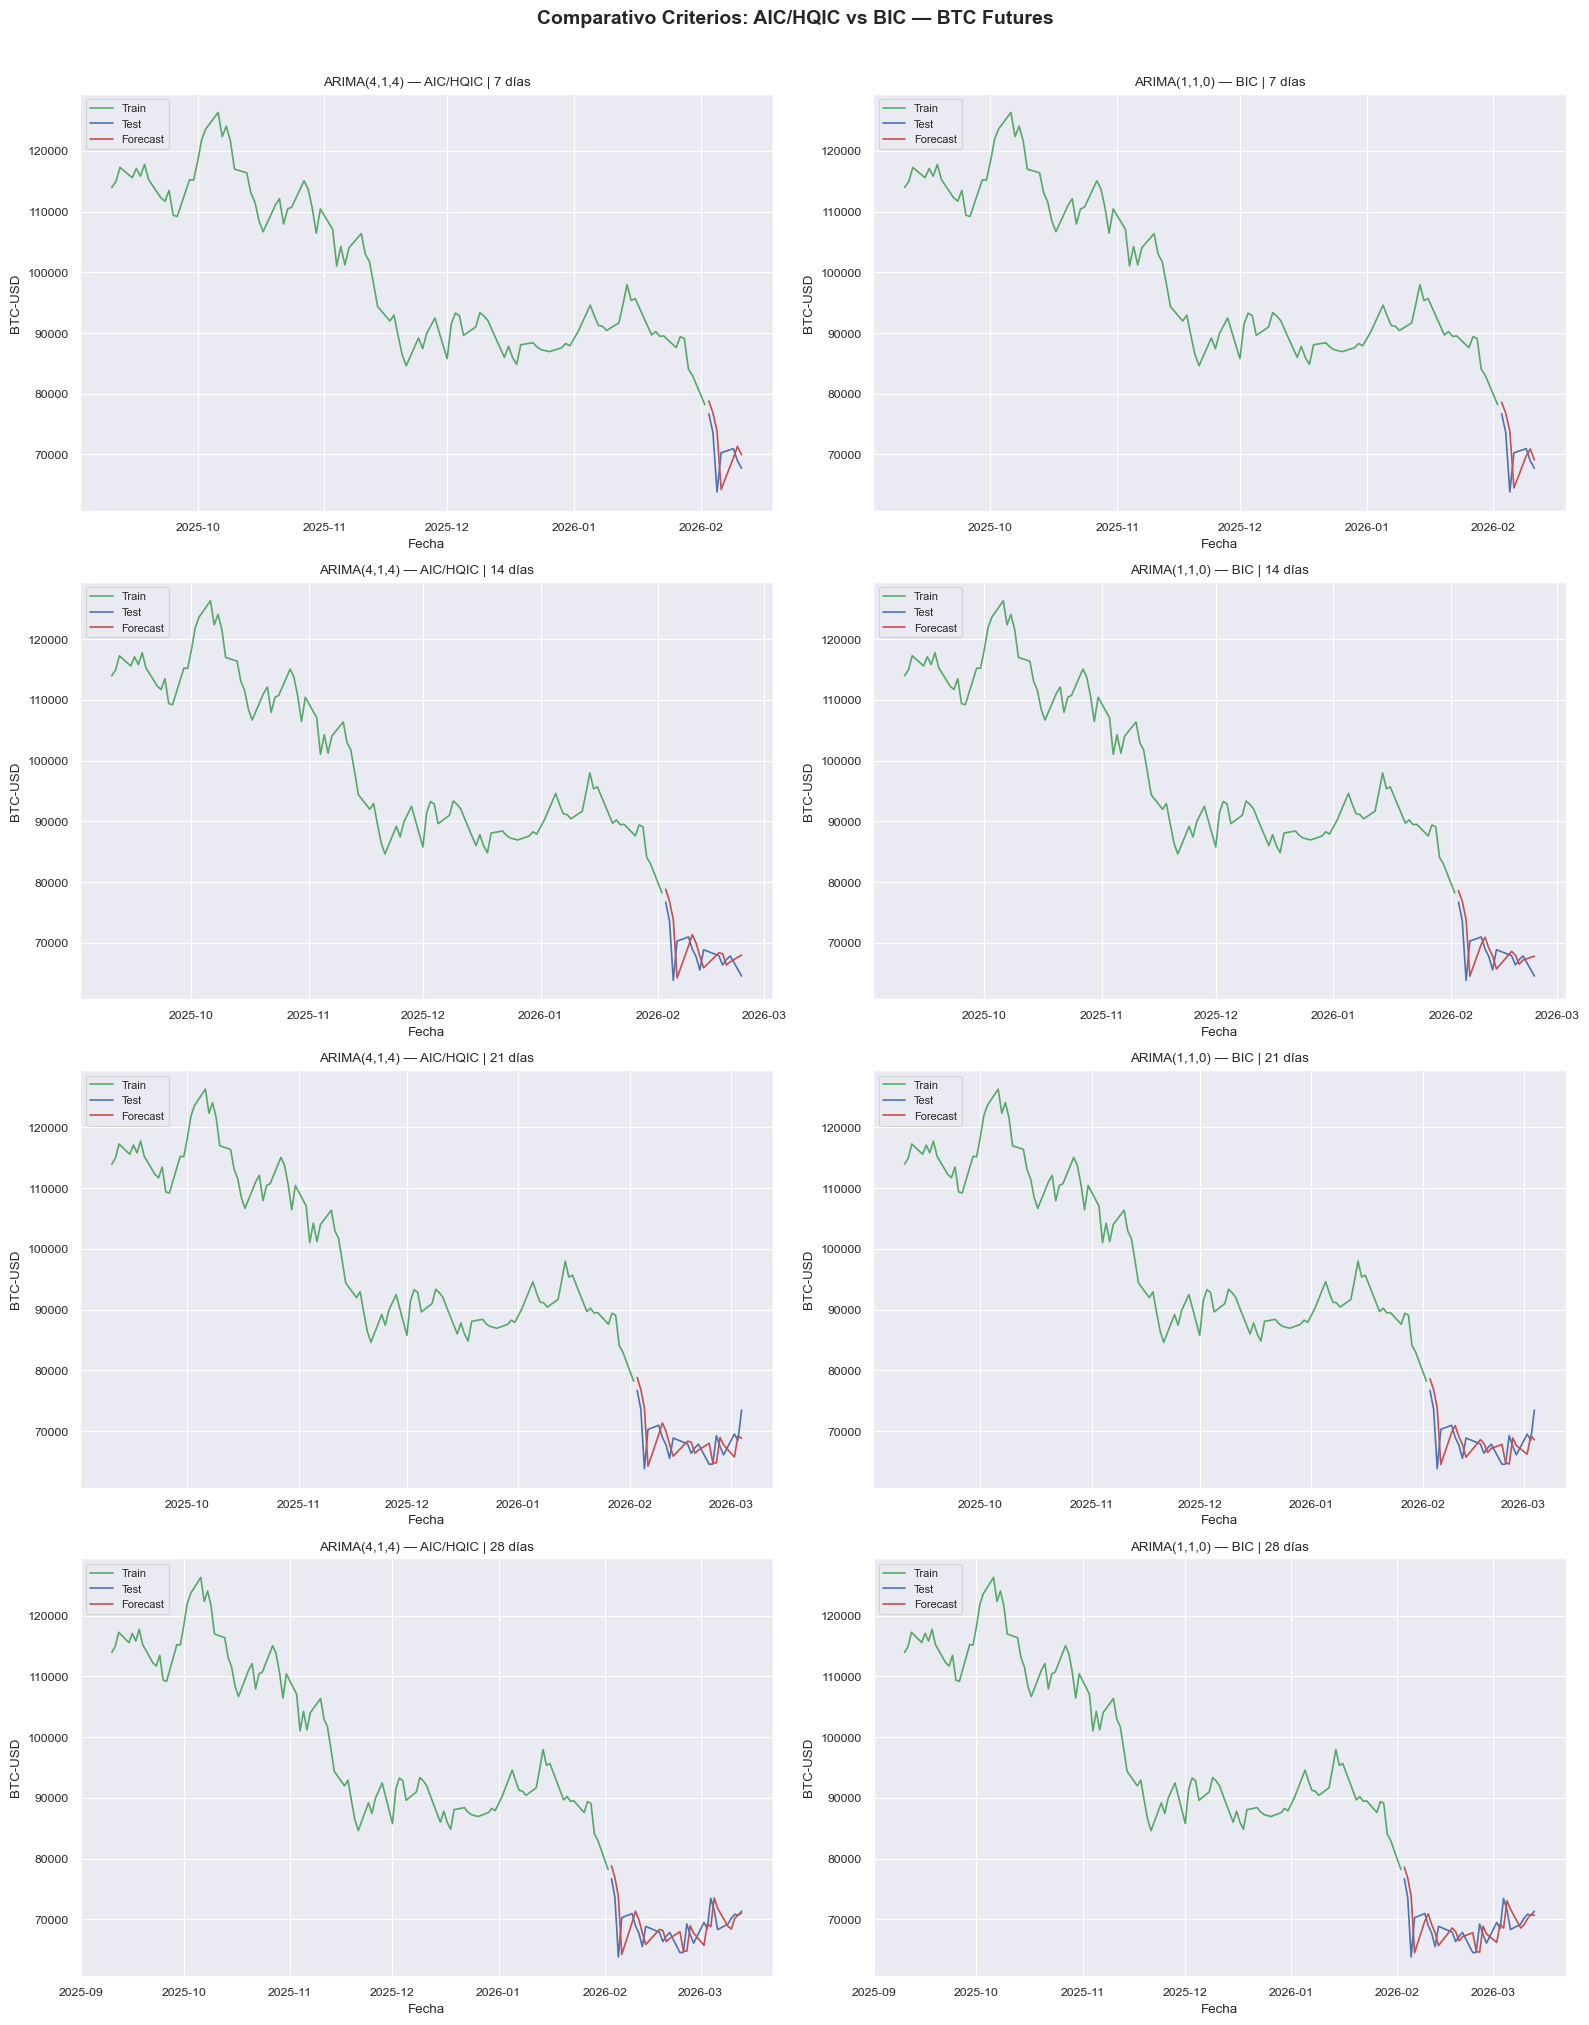

In [105]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20))

horizontes = [
    (test_7,  yhat_7,     yhat_bic_7,  dates_7,  "7 días"),
    (test_14, yhat_14,    yhat_bic_14, dates_14, "14 días"),
    (test_21, yhat_21,    yhat_bic_21, dates_21, "21 días"),
    (test_28, yhat_28,    yhat_bic_28, dates_28, "28 días"),
]

for row, (test, yhat_a, yhat_b, dates, label) in enumerate(horizontes):

    # --- Columna izquierda: AIC/HQIC ---
    ax = axes[row, 0]
    sns.lineplot(x=dates_train[-100:], y=train[-100:],
                 label="Train",    color='g', ax=ax)
    sns.lineplot(x=dates, y=test.tolist(),
                 label="Test",     color='b', ax=ax)
    sns.lineplot(x=dates, y=yhat_a,
                 label="Forecast", color='r', ax=ax)
    ax.set_title(f"ARIMA(4,1,4) — AIC/HQIC | {label}")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("BTC-USD")
    ax.legend(loc='upper left', fontsize=8)

    # --- Columna derecha: BIC ---
    ax = axes[row, 1]
    sns.lineplot(x=dates_train[-100:], y=train[-100:],
                 label="Train",    color='g', ax=ax)
    sns.lineplot(x=dates, y=test.tolist(),
                 label="Test",     color='b', ax=ax)
    sns.lineplot(x=dates, y=yhat_b,
                 label="Forecast", color='r', ax=ax)
    ax.set_title(f"ARIMA(1,1,0) — BIC | {label}")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("BTC-USD")
    ax.legend(loc='upper left', fontsize=8)

plt.suptitle("Comparativo Criterios: AIC/HQIC vs BIC — BTC Futures",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Análisis Comparativo: Criterios AIC vs HQIC vs BIC

### Modelos seleccionados
| Criterio | Modelo        | Valor del criterio | Penalización     |
|----------|---------------|--------------------|------------------|
| AIC      | ARIMA(4,1,4)  | 35,998.75          | 2k               |
| HQIC     | ARIMA(4,1,4)  | 36,017.31          | 2k·ln(ln(n))     |
| BIC      | ARIMA(1,1,0)  | 36,036.58          | k·ln(n)          |

### Tabla comparativa de métricas — Rolling Forecast

| Horizonte | MAE (AIC/HQIC) | MAE (BIC) | MAPE (AIC/HQIC) | MAPE (BIC) | RMSE (AIC/HQIC) | RMSE (BIC) |
|-----------|----------------|-----------|-----------------|------------|-----------------|------------|
| 7 días    | 3,934.41       | 3,635.73  | 5.76%           | 5.33%      | 4,849.90        | 4,702.58   |
| 14 días   | 2,888.06       | 2,710.85  | 4.27%           | 4.01%      | 3,742.53        | 3,634.67   |
| 21 días   | 2,734.35       | 2,605.47  | 4.00%           | 3.82%      | 3,501.25        | 3,426.61   |
| 28 días   | 2,360.45       | 2,243.96  | 3.45%           | 3.28%      | 3,149.18        | 3,064.09   |

### Interpretación

**Sobre los criterios de selección:**
- Los tres criterios difieren en la severidad con que penalizan la 
  complejidad del modelo. AIC es el más permisivo, HQIC tiene una 
  penalización intermedia y BIC es el más restrictivo.
- En este caso particular, AIC y HQIC seleccionaron el mismo modelo 
  ARIMA(4,1,4). Esto no significa que sean equivalentes, sino que con 
  n=2,072 observaciones, la penalización del HQIC (2k·ln(ln(2072)) ≈ 1.97k) 
  resulta numéricamente muy cercana a la del AIC (2k), lo que llevó a 
  ambos criterios a favorecer el mismo orden.
- BIC, con su penalización k·ln(2072) ≈ 7.64k, es considerablemente 
  más estricto y seleccionó el modelo más parsimonioso: ARIMA(1,1,0).

**Sobre el desempeño predictivo:**
- A pesar de ser considerablemente más simple, el modelo seleccionado 
  por **BIC supera al AIC/HQIC en todos los horizontes y todas las métricas**.
- La reducción del MAPE oscila entre **0.17% y 0.43%** a favor del BIC,
  lo que sugiere que los parámetros adicionales del ARIMA(4,1,4) no 
  aportan capacidad predictiva real y podrían estar introduciendo 
  sobreajuste sobre el conjunto de entrenamiento.

**Sobre los gráficos:**
- Visualmente ambos modelos siguen de manera muy similar la trayectoria 
  real del precio de Bitcoin, siendo difícil distinguirlos a simple vista.
- La diferencia se hace más evidente en las métricas numéricas, donde 
  el modelo BIC muestra consistentemente menor error.

**Conclusión:**
En este caso, el principio de parsimonia favorece al modelo seleccionado 
por BIC. Un modelo más simple ARIMA(1,1,0) logra mejores predicciones 
que uno más complejo ARIMA(4,1,4), lo que refuerza que para series 
financieras de alta volatilidad como Bitcoin, agregar más parámetros 
no necesariamente mejora la capacidad de pronóstico.

## Inciso 6
Escriba en cada paso las conclusiones y análisis estadísticos asociados con los resultados obtenidos. Realice tests de normalidad e independencia para los residuales obtenidos para cada predicción, en cada caso agregue las correspondientes conclusiones. Figuras y algoritmos que no estén acompañados de una conclusión, descripción y análisis estadístico, no serán tenidas en cuenta.

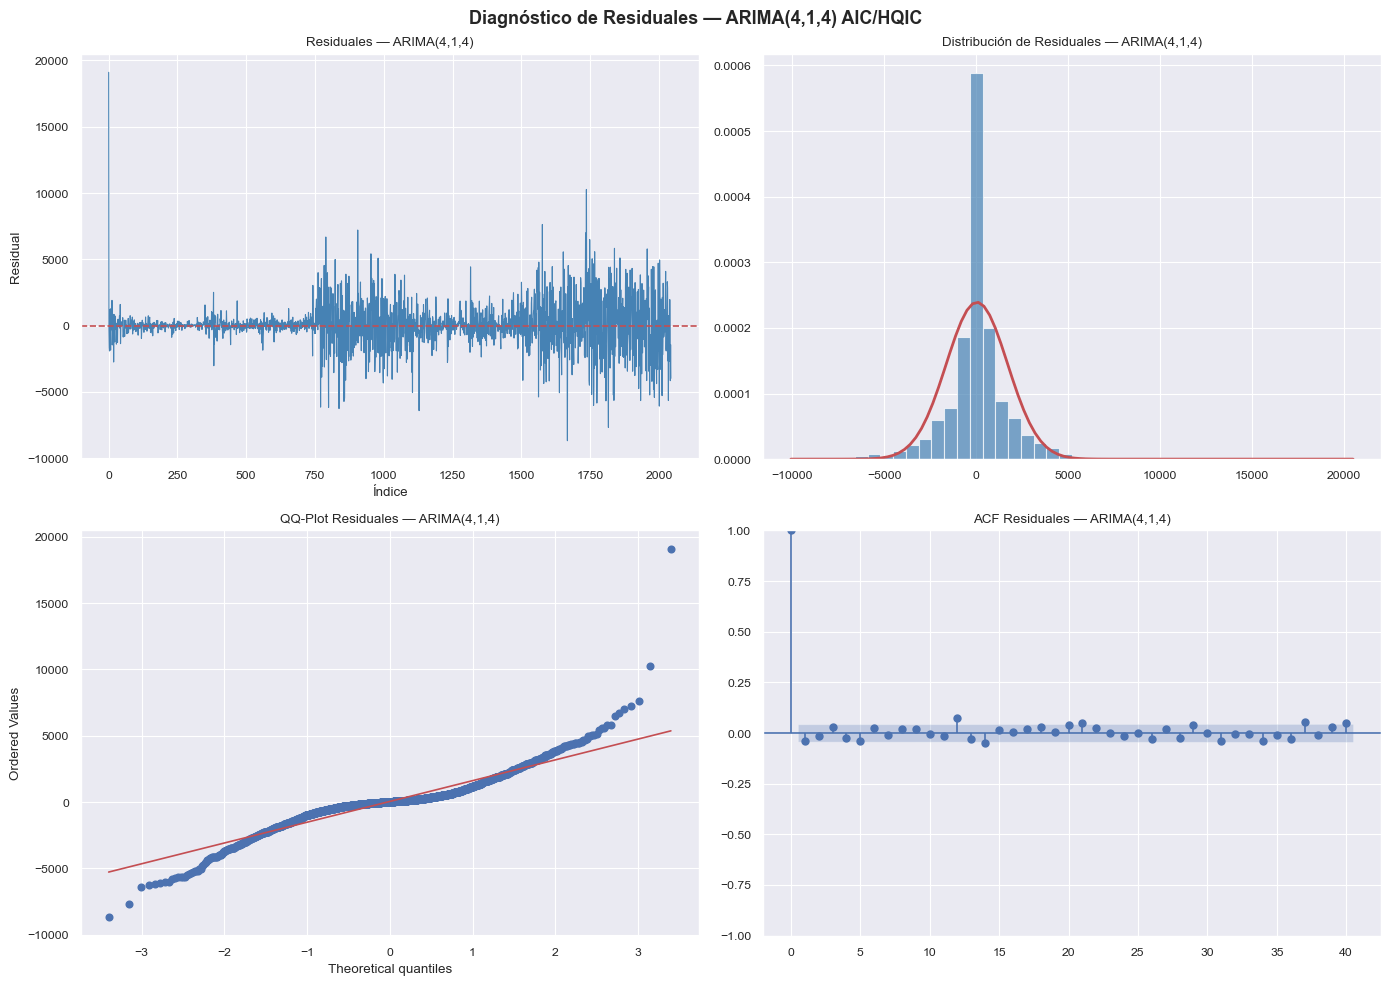

TESTS DE RESIDUALES — ARIMA(4,1,4) AIC/HQIC

[Normalidad] Shapiro-Wilk:
  Estadístico = 0.882655 | p-value = 0.000000
  → p ≤ 0.05: Rechazamos H₀ → Residuales NO normales

[Normalidad] Jarque-Bera:
  Estadístico = 11645.606328 | p-value = 0.000000
  → p ≤ 0.05: Rechazamos H₀ → Residuales NO normales

[Independencia] Ljung-Box:
      lb_stat  lb_pvalue
10  13.923282   0.176520
20  38.281548   0.008180
30  52.607646   0.006545
  → Algún p ≤ 0.05: Rechazamos H₀ → Residuales NO independientes


In [106]:
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox

# Residuales del modelo AIC/HQIC
residuales_aic = model_fit.resid

# --- Gráficos de diagnóstico ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Serie de residuales
axes[0, 0].plot(residuales_aic, color='steelblue', linewidth=0.8)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_title("Residuales — ARIMA(4,1,4)")
axes[0, 0].set_xlabel("Índice")
axes[0, 0].set_ylabel("Residual")

# 2. Histograma + curva normal
axes[0, 1].hist(residuales_aic, bins=40, density=True, 
                color='steelblue', alpha=0.7, edgecolor='white')
xmin, xmax = axes[0, 1].get_xlim()
x = np.linspace(xmin, xmax, 100)
axes[0, 1].plot(x, stats.norm.pdf(x, residuales_aic.mean(), 
                residuales_aic.std()), 'r-', linewidth=2)
axes[0, 1].set_title("Distribución de Residuales — ARIMA(4,1,4)")

# 3. QQ-Plot
stats.probplot(residuales_aic, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("QQ-Plot Residuales — ARIMA(4,1,4)")

# 4. ACF de residuales
plot_acf(residuales_aic, ax=axes[1, 1], lags=40)
axes[1, 1].set_title("ACF Residuales — ARIMA(4,1,4)")

plt.suptitle("Diagnóstico de Residuales — ARIMA(4,1,4) AIC/HQIC",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Tests estadísticos ---
print("=" * 55)
print("TESTS DE RESIDUALES — ARIMA(4,1,4) AIC/HQIC")
print("=" * 55)

# Normalidad: Shapiro-Wilk
stat_sw, p_sw = stats.shapiro(residuales_aic)
print(f"\n[Normalidad] Shapiro-Wilk:")
print(f"  Estadístico = {stat_sw:.6f} | p-value = {p_sw:.6f}")
if p_sw > 0.05:
    print("  → p > 0.05: No rechazamos H₀ → Residuales NORMALES")
else:
    print("  → p ≤ 0.05: Rechazamos H₀ → Residuales NO normales")

# Normalidad: Jarque-Bera
stat_jb, p_jb = stats.jarque_bera(residuales_aic)
print(f"\n[Normalidad] Jarque-Bera:")
print(f"  Estadístico = {stat_jb:.6f} | p-value = {p_jb:.6f}")
if p_jb > 0.05:
    print("  → p > 0.05: No rechazamos H₀ → Residuales NORMALES")
else:
    print("  → p ≤ 0.05: Rechazamos H₀ → Residuales NO normales")

# Independencia: Ljung-Box
lb_test = acorr_ljungbox(residuales_aic, lags=[10, 20, 30], return_df=True)
print(f"\n[Independencia] Ljung-Box:")
print(lb_test.round(6))
if (lb_test['lb_pvalue'] > 0.05).all():
    print("  → Todos p > 0.05: No rechazamos H₀ → Residuales INDEPENDIENTES")
else:
    print("  → Algún p ≤ 0.05: Rechazamos H₀ → Residuales NO independientes")

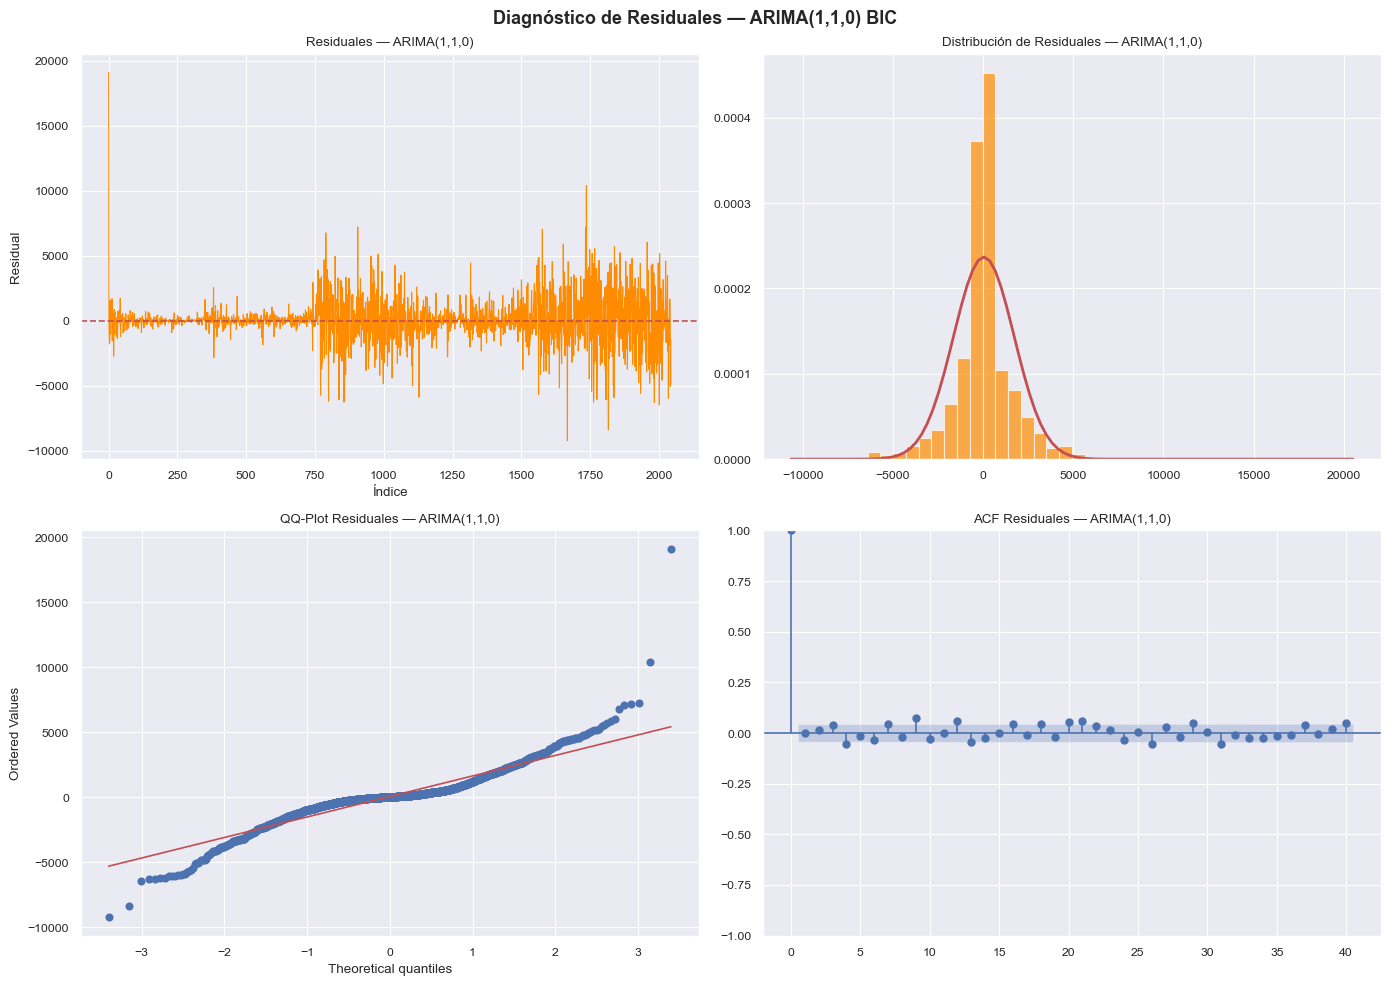

TESTS DE RESIDUALES — ARIMA(1,1,0) BIC

[Normalidad] Shapiro-Wilk:
  Estadístico = 0.878674 | p-value = 0.000000
  → p ≤ 0.05: Rechazamos H₀ → Residuales NO normales

[Normalidad] Jarque-Bera:
  Estadístico = 11353.685926 | p-value = 0.000000
  → p ≤ 0.05: Rechazamos H₀ → Residuales NO normales

[Independencia] Ljung-Box:
      lb_stat  lb_pvalue
10  29.888211   0.000893
20  55.506671   0.000034
30  80.913535   0.000001
  → Algún p ≤ 0.05: Rechazamos H₀ → Residuales NO independientes


In [107]:
# Residuales del modelo BIC
residuales_bic = best_mdl_bic.resid

# --- Gráficos de diagnóstico ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Serie de residuales
axes[0, 0].plot(residuales_bic, color='darkorange', linewidth=0.8)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_title("Residuales — ARIMA(1,1,0)")
axes[0, 0].set_xlabel("Índice")
axes[0, 0].set_ylabel("Residual")

# 2. Histograma + curva normal
axes[0, 1].hist(residuales_bic, bins=40, density=True,
                color='darkorange', alpha=0.7, edgecolor='white')
xmin, xmax = axes[0, 1].get_xlim()
x = np.linspace(xmin, xmax, 100)
axes[0, 1].plot(x, stats.norm.pdf(x, residuales_bic.mean(),
                residuales_bic.std()), 'r-', linewidth=2)
axes[0, 1].set_title("Distribución de Residuales — ARIMA(1,1,0)")

# 3. QQ-Plot
stats.probplot(residuales_bic, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("QQ-Plot Residuales — ARIMA(1,1,0)")

# 4. ACF de residuales
plot_acf(residuales_bic, ax=axes[1, 1], lags=40)
axes[1, 1].set_title("ACF Residuales — ARIMA(1,1,0)")

plt.suptitle("Diagnóstico de Residuales — ARIMA(1,1,0) BIC",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Tests estadísticos ---
print("=" * 55)
print("TESTS DE RESIDUALES — ARIMA(1,1,0) BIC")
print("=" * 55)

# Normalidad: Shapiro-Wilk
stat_sw2, p_sw2 = stats.shapiro(residuales_bic)
print(f"\n[Normalidad] Shapiro-Wilk:")
print(f"  Estadístico = {stat_sw2:.6f} | p-value = {p_sw2:.6f}")
if p_sw2 > 0.05:
    print("  → p > 0.05: No rechazamos H₀ → Residuales NORMALES")
else:
    print("  → p ≤ 0.05: Rechazamos H₀ → Residuales NO normales")

# Normalidad: Jarque-Bera
stat_jb2, p_jb2 = stats.jarque_bera(residuales_bic)
print(f"\n[Normalidad] Jarque-Bera:")
print(f"  Estadístico = {stat_jb2:.6f} | p-value = {p_jb2:.6f}")
if p_jb2 > 0.05:
    print("  → p > 0.05: No rechazamos H₀ → Residuales NORMALES")
else:
    print("  → p ≤ 0.05: Rechazamos H₀ → Residuales NO normales")

# Independencia: Ljung-Box
lb_test2 = acorr_ljungbox(residuales_bic, lags=[10, 20, 30], return_df=True)
print(f"\n[Independencia] Ljung-Box:")
print(lb_test2.round(6))
if (lb_test2['lb_pvalue'] > 0.05).all():
    print("  → Todos p > 0.05: No rechazamos H₀ → Residuales INDEPENDIENTES")
else:
    print("  → Algún p ≤ 0.05: Rechazamos H₀ → Residuales NO independientes")

## Diagnóstico de Residuales: Tests de Normalidad e Independencia

### Resumen de resultados

| Test                  | ARIMA(4,1,4) AIC/HQIC        | ARIMA(1,1,0) BIC             |
|-----------------------|------------------------------|------------------------------|
| Shapiro-Wilk (p-val)  | 0.000000 → NO normal         | 0.000000 → NO normal         |
| Jarque-Bera (p-val)   | 0.000000 → NO normal         | 0.000000 → NO normal         |
| Ljung-Box lag 10      | 0.1765 → independientes      | 0.000893 → NO independientes |
| Ljung-Box lag 20      | 0.0082 → NO independientes   | 0.000034 → NO independientes |
| Ljung-Box lag 30      | 0.0065 → NO independientes   | 0.000001 → NO independientes |

### Normalidad

**Ambos modelos rechazan la hipótesis de normalidad** con p-value = 0.000 
en Shapiro-Wilk y Jarque-Bera. Esto es confirmado visualmente por:
- El **histograma**: muestra una distribución leptocúrtica (cola derecha 
  muy larga), alejada de la curva normal teórica.
- El **QQ-Plot**: los puntos se desvían notoriamente de la línea teórica 
  en ambas colas, especialmente en la cola derecha, evidenciando la 
  presencia de valores extremos (outliers).

Esto es consistente con la naturaleza del precio de Bitcoin, cuya 
distribución de cambios presenta **colas pesadas** producto de eventos 
extremos como los crashes de 2018, 2020 y 2022, y los rallies de 2021 
y 2024.

### Independencia

**ARIMA(4,1,4):** Los residuales muestran independencia a lag 10 
(p=0.177), pero la pierden a partir de lag 20 (p=0.008) y lag 30 
(p=0.007). Esto sugiere que el modelo captura adecuadamente la 
autocorrelación de corto plazo, pero deja estructura sin modelar 
en horizontes más largos.

**ARIMA(1,1,0):** Los residuales **no son independientes en ningún 
lag** (p < 0.001 en todos los casos). Esto indica que el modelo 
más simple no logra capturar toda la estructura de autocorrelación 
presente en la serie, dejando dependencia significativa sin modelar.

La ACF de los residuales confirma este resultado: ambos modelos 
muestran la mayoría de los lags dentro de las bandas de confianza, 
pero el ARIMA(1,1,0) presenta más lags significativos fuera de 
las bandas que el ARIMA(4,1,4).

### Conclusión general

Ninguno de los dos modelos cumple completamente los supuestos 
clásicos de un modelo ARIMA bien especificado (residuales normales 
e independientes). Esto se explica por la **heterocedasticidad 
condicional** característica de los activos financieros: la 
varianza de los residuales no es constante en el tiempo, 
creciendo en períodos de alta volatilidad como se aprecia 
claramente en los gráficos de la serie de residuales.

El ARIMA(4,1,4) muestra un mejor comportamiento en independencia 
a corto plazo frente al ARIMA(1,1,0), lo que es consistente con 
su mayor número de parámetros AR y MA para capturar autocorrelación. 
Sin embargo, ambos modelos señalan la necesidad de extender el 
análisis hacia modelos que capturen varianza condicional, como 
**GARCH** o **ARIMA-GARCH**.